# EV Adoption Drivers: A Country-Year Panel Analysis

### Question
Which policy, infrastructure, cost and economic conditions are associated with higher electric vehicle adoption, and how robust are those associations once time trends, collinearity and the small number of countries are taken into account?

### Data
A balanced panel of **25 countries in 5 regions, 2010 to 2025**, split into three vehicle segments (premium, mass market, commercial): 1,200 rows covering EV, petrol and diesel sales together with country-year drivers such as charging infrastructure, fuel and electricity prices, EV subsidies, emission regulation, GDP per capita and urbanization.

*Source:* course-provided dataset. Its original generation process and external provenance are not documented in the supplied materials, so the results describe patterns in this panel and have not been validated against official vehicle registration data.

### Structure
1. **Data validation:** grain, KPI consistency, data-quality issues, segment differences
2. **Adoption snapshot:** leaders by share and by volume
3. **Trends:** EV vs ICE over time, segment diffusion, fastest acceleration
4. **Driver analysis:** correlations, then a statistical model of EV share
5. **EV-dominant markets:** what distinguishes markets above 50% share
6. **Adoption patterns:** recurring combinations of market conditions
7. **Implications** for regulators, charging operators and automakers

### Methods
pandas and NumPy for data preparation; Spearman correlation with within-year controls; OLS on a logit-transformed outcome with year fixed effects and country-clustered standard errors (statsmodels); a Webb wild cluster bootstrap for small-cluster inference; variance decomposition and two-way fixed effects; VIF and alternative specifications for robustness; Matplotlib for visualization.

All findings are observational associations, not causal effects.

## Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# Validated categorical palette (fixed order, never cycled)
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEG_COLORS = {"premium": PALETTE[0], "mass_market": PALETTE[1], "commercial": PALETTE[2]}

# Recessive grid and axes, thin lines
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e4e3df",
    "grid.linewidth": 0.8,
    "axes.edgecolor": "#8a8984",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "lines.linewidth": 2,
    "legend.frameon": False,
})

# Place end-of-line labels without overlap (min vertical gap in data units)
def end_labels(ax, items, gap):
    items = sorted(items, key=lambda t: t[1])
    ys = []
    for _, y, _ in items:
        ys.append(max(y, ys[-1] + gap) if ys else y)
    for (text, y, x), yl in zip(items, ys):
        ax.annotate(text, (x, y), xytext=(x + 0.3, yl), va="center", fontsize=9, color="#52514e")

# Load the dataset
FILE = "ev_vs_petrol_dataset_v31.csv"

raw = pd.read_csv(FILE)
df = raw.copy()

print(df.shape)
df.head()

(1200, 22)


,country,region,year,vehicle_segment,powertrain_type,ev_sales,petrol_car_sales,diesel_car_sales,total_vehicle_sales,ev_market_share,charging_stations,fast_chargers_share,avg_ev_range_km,fuel_price_usd_per_liter,electricity_price_usd_per_kwh,gdp_per_capita,urban_population_percent,co2_emissions_transport_mt,ev_subsidy_usd,emission_regulation_score,ev_growth_rate_yoy,is_ev_dominant
0,Australia,Oceania,2010,commercial,ICE,5,92877,61921,154803,0.000,0,0.000,124,1.090,0.149,51977,88.800,88.700,0,30.400,0.000,0
1,Australia,Oceania,2010,mass_market,ICE,57,535933,73089,609079,0.010,0,0.000,124,1.090,0.149,51977,88.800,88.700,0,30.400,0.000,0
2,Australia,Oceania,2010,premium,ICE,37,235282,20462,255781,0.010,0,0.000,124,1.090,0.149,51977,88.800,88.700,0,30.400,0.000,0
3,Australia,Oceania,2011,commercial,ICE,11,98092,65395,163498,0.010,105,1.500,133,1.090,0.163,52807,88.900,88.300,0,30.800,120.000,0
4,Australia,Oceania,2011,mass_market,ICE,129,569679,77684,647492,0.020,105,1.500,133,1.090,0.163,52807,88.900,88.300,0,30.800,126.320,0


---
# 1. Dataset Understanding & Metric Definitions
## 1.1 Size, time coverage and unique values

In [2]:
print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
print(f"Years: {df.year.min()} to {df.year.max()} ({df.year.nunique()} years)")

# Unique values of the categorical keys
for col in ["country", "region", "year", "vehicle_segment", "powertrain_type"]:
    vals = sorted(df[col].unique())
    print(f"\n{col}: {len(vals)} unique")
    print(vals)

Rows: 1,200 | Columns: 22
Years: 2010 to 2025 (16 years)

country: 25 unique
['Australia', 'Austria', 'Belgium', 'Brazil', 'Canada', 'China', 'France', 'Germany', 'India', 'Indonesia', 'Italy', 'Japan', 'Mexico', 'Netherlands', 'Norway', 'Poland', 'Portugal', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Thailand', 'Turkey', 'United Kingdom', 'United States']

region: 5 unique
['APAC', 'Europe', 'North America', 'Oceania', 'South America']

year: 16 unique
[np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

vehicle_segment: 3 unique
['commercial', 'mass_market', 'premium']

powertrain_type: 2 unique
['BEV', 'ICE']


In [3]:
# Grain check: exactly one row per country x year x segment
grain = df.groupby(["country", "year", "vehicle_segment"]).size()
print("Rows per country-year-segment:", grain.value_counts().to_dict())
print("Expected rows (25 x 16 x 3):", df.country.nunique() * df.year.nunique() * df.vehicle_segment.nunique())

# Country to region mapping (each country should sit in one region)
region_map = df.groupby("region").country.unique().apply(sorted)
region_map.to_frame("countries").assign(n=region_map.str.len())

Rows per country-year-segment: {1: 1200}
Expected rows (25 x 16 x 3): 1200


,countries,n
region,,
APAC,"[China, India, Indonesia, Japan, South Korea, ...",6
Europe,"[Austria, Belgium, France, Germany, Italy, Net...",14
North America,"[Canada, Mexico, United States]",3
Oceania,[Australia],1
South America,[Brazil],1


## 1.2 Variable dictionary: outcomes vs drivers

In [4]:
TARGETS = ["ev_sales", "ev_market_share", "ev_growth_rate_yoy", "is_ev_dominant"]
DRIVER_GROUPS = {
    "Infrastructure": ["charging_stations", "fast_chargers_share"],
    "Cost signals": ["fuel_price_usd_per_liter", "electricity_price_usd_per_kwh"],
    "Policy": ["ev_subsidy_usd", "emission_regulation_score"],
    "Macro": ["gdp_per_capita", "urban_population_percent"],
}
DRIVERS = [d for g in DRIVER_GROUPS.values() for d in g]
OTHER = ["petrol_car_sales", "diesel_car_sales", "total_vehicle_sales", "avg_ev_range_km", "co2_emissions_transport_mt", "powertrain_type"]

rows = [(t, "Outcome (target)") for t in TARGETS]
rows += [(d, f"Driver: {g}") for g, ds in DRIVER_GROUPS.items() for d in ds]
rows += [(o, "Context / volume") for o in OTHER]
dictionary = pd.DataFrame(rows, columns=["column", "role"])
dictionary["dtype"] = dictionary.column.map(df.dtypes.astype(str))
dictionary["min"] = dictionary.column.map(lambda c: df[c].min() if df[c].dtype != object else "")
dictionary["max"] = dictionary.column.map(lambda c: df[c].max() if df[c].dtype != object else "")
dictionary

,column,role,dtype,min,max
0,ev_sales,Outcome (target),int64,5,7670056
1,ev_market_share,Outcome (target),float64,0.000,95.000
2,ev_growth_rate_yoy,Outcome (target),float64,-40.960,300.000
3,is_ev_dominant,Outcome (target),int64,0,1
4,charging_stations,Driver: Infrastructure,int64,0,4338106
5,fast_chargers_share,Driver: Infrastructure,float64,0.000,49.300
6,fuel_price_usd_per_liter,Driver: Cost signals,float64,0.483,2.153
7,electricity_price_usd_per_kwh,Driver: Cost signals,float64,0.067,0.379
8,ev_subsidy_usd,Driver: Policy,int64,0,8952
9,emission_regulation_score,Driver: Policy,float64,19.484,95.602


In [5]:
# Are drivers measured per country-year (same value across the 3 segments)?
ctx_cols = DRIVERS + ["avg_ev_range_km", "co2_emissions_transport_mt"]
n_distinct = df.groupby(["country", "year"])[ctx_cols].nunique().max()
print("Max distinct values within a country-year:")
print(n_distinct.to_string())

Max distinct values within a country-year:
charging_stations                1
fast_chargers_share              1
fuel_price_usd_per_liter         1
electricity_price_usd_per_kwh    1
ev_subsidy_usd                   1
emission_regulation_score        1
gdp_per_capita                   1
urban_population_percent         1
avg_ev_range_km                  1
co2_emissions_transport_mt       1


## 1.3 Data quality checks: missing values and labels

In [6]:
# Missing values by column
missing_col = df.isna().sum().to_frame("n_missing")
missing_col["pct"] = missing_col.n_missing / len(df) * 100
print("Total missing cells:", int(df.isna().sum().sum()))

# Missing values by country
missing_country = df.drop(columns="country").isna().groupby(df.country).sum().sum(axis=1)
print("Countries with any missing value:", int((missing_country > 0).sum()))
missing_col.T

Total missing cells: 0
Countries with any missing value: 0


,country,region,year,vehicle_segment,powertrain_type,ev_sales,petrol_car_sales,diesel_car_sales,total_vehicle_sales,ev_market_share,charging_stations,fast_chargers_share,avg_ev_range_km,fuel_price_usd_per_liter,electricity_price_usd_per_kwh,gdp_per_capita,urban_population_percent,co2_emissions_transport_mt,ev_subsidy_usd,emission_regulation_score,ev_growth_rate_yoy,is_ev_dominant
n_missing,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
pct,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [7]:
# Inconsistent labels: stray whitespace, case variants, near-duplicate spellings
label_report = []
for col in ["country", "region", "vehicle_segment", "powertrain_type"]:
    s = df[col].astype(str)
    label_report.append({
        "column": col,
        "n_unique_raw": s.nunique(),
        "n_unique_normalized": s.str.strip().str.lower().str.replace(r"[\s_-]+", " ", regex=True).nunique(),
        "rows_with_extra_whitespace": int((s != s.str.strip()).sum()),
    })
pd.DataFrame(label_report)

,column,n_unique_raw,n_unique_normalized,rows_with_extra_whitespace
0,country,25,25,0
1,region,5,5,0
2,vehicle_segment,3,3,0
3,powertrain_type,2,2,0


## 1.4 KPI logic checks

In [8]:
# Check 1: ev_sales <= total_vehicle_sales
chk_ev_le_total = (df.ev_sales <= df.total_vehicle_sales)

# Check 2: total = EV + petrol + diesel (identity)
chk_identity = (df.ev_sales + df.petrol_car_sales + df.diesel_car_sales == df.total_vehicle_sales)

# Check 3: ev_market_share ~= ev_sales / total_vehicle_sales (share is in percent, rounded to 2 dp)
df["share_calc"] = df.ev_sales / df.total_vehicle_sales * 100
df["share_abs_diff"] = (df.share_calc - df.ev_market_share).abs()
TOL = 0.01
chk_share = df.share_abs_diff <= TOL

kpi_checks = pd.DataFrame({
    "check": ["ev_sales <= total_vehicle_sales", "total = ev + petrol + diesel", f"|share_calc - ev_market_share| <= {TOL} pp"],
    "rows_passing": [chk_ev_le_total.sum(), chk_identity.sum(), chk_share.sum()],
    "rows_failing": [(~chk_ev_le_total).sum(), (~chk_identity).sum(), (~chk_share).sum()],
})
print(f"Max share difference: {df.share_abs_diff.max():.4f} pp (consistent with 2-decimal rounding)")
kpi_checks

Max share difference: 0.0050 pp (consistent with 2-decimal rounding)


,check,rows_passing,rows_failing
0,ev_sales <= total_vehicle_sales,1200,0
1,total = ev + petrol + diesel,1200,0
2,|share_calc - ev_market_share| <= 0.01 pp,1200,0


In [9]:
# Check 4: ev_growth_rate_yoy vs recomputed % change in ev_sales within country-segment
df = df.sort_values(["country", "vehicle_segment", "year"]).reset_index(drop=True)
df["growth_calc"] = df.groupby(["country", "vehicle_segment"]).ev_sales.pct_change() * 100

base_year = df.year == df.year.min()
print("Base-year (2010) growth values:", df.loc[base_year, "ev_growth_rate_yoy"].unique())
print("Rows capped at 300%:", int((df.ev_growth_rate_yoy == 300).sum()),
      "| of which true growth > 300%:", int(((df.ev_growth_rate_yoy == 300) & (df.growth_calc > 300)).sum()))

# Compare after applying the 300% cap to the recomputed value
nb = df[~base_year].copy()
nb["growth_diff"] = (nb.growth_calc.clip(upper=300) - nb.ev_growth_rate_yoy).abs()
growth_bad = nb[nb.growth_diff > 0.01]
print(f"Rows where reported growth != recomputed growth: {len(growth_bad)} of {len(nb)} ({len(growth_bad)/len(nb):.1%})")
print("Mismatches by year:", growth_bad.year.value_counts().sort_index().to_dict())
print(f"Median ev_sales in mismatched rows: {growth_bad.ev_sales.median():,.0f} vs {nb.ev_sales.median():,.0f} overall")
growth_bad[["country", "year", "vehicle_segment", "ev_sales", "ev_growth_rate_yoy", "growth_calc"]].head(8)

Base-year (2010) growth values: [0.]
Rows capped at 300%: 43 | of which true growth > 300%: 43
Rows where reported growth != recomputed growth: 152 of 1125 (13.5%)
Mismatches by year: {2012: 32, 2013: 30, 2014: 27, 2015: 21, 2016: 16, 2017: 9, 2018: 7, 2019: 5, 2020: 4, 2021: 1}
Median ev_sales in mismatched rows: 52 vs 3,416 overall


,country,year,vehicle_segment,ev_sales,ev_growth_rate_yoy,growth_calc
2,Australia,2012,commercial,17,84.390,54.545
3,Australia,2013,commercial,36,93.100,111.765
4,Australia,2014,commercial,53,68.900,47.222
5,Australia,2015,commercial,77,65.460,45.283
6,Australia,2016,commercial,105,42.880,36.364
34,Australia,2012,premium,117,77.820,46.250
50,Austria,2012,commercial,12,30.930,71.429
51,Austria,2013,commercial,16,31.730,33.333


In [10]:
# Check 5: meaning of the two label columns
print("is_ev_dominant = 1 -> share range:", df.loc[df.is_ev_dominant == 1, "ev_market_share"].agg(["min", "max"]).tolist())
print("is_ev_dominant = 0 -> share range:", df.loc[df.is_ev_dominant == 0, "ev_market_share"].agg(["min", "max"]).tolist())
print("powertrain_type = BEV -> share range:", df.loc[df.powertrain_type == "BEV", "ev_market_share"].agg(["min", "max"]).tolist())
print("powertrain_type = ICE -> share range:", df.loc[df.powertrain_type == "ICE", "ev_market_share"].agg(["min", "max"]).tolist())
pd.crosstab(df.powertrain_type, df.is_ev_dominant, margins=True)

is_ev_dominant = 1 -> share range: [50.56, 95.0]
is_ev_dominant = 0 -> share range: [0.0, 49.87]
powertrain_type = BEV -> share range: [40.69, 95.0]
powertrain_type = ICE -> share range: [0.0, 39.97]


is_ev_dominant,0,1,All
powertrain_type,,,
BEV,14,22,36
ICE,1164,0,1164
All,1178,22,1200


## 1.5 Outliers and boundary values

In [11]:
# IQR outlier counts for numeric columns
num_cols = ["ev_sales", "total_vehicle_sales", "ev_market_share", "ev_growth_rate_yoy", "charging_stations",
            "fast_chargers_share", "fuel_price_usd_per_liter", "electricity_price_usd_per_kwh",
            "ev_subsidy_usd", "emission_regulation_score", "gdp_per_capita", "urban_population_percent"]
q1, q3 = df[num_cols].quantile(0.25), df[num_cols].quantile(0.75)
iqr = q3 - q1
outliers = ((df[num_cols] < q1 - 1.5 * iqr) | (df[num_cols] > q3 + 1.5 * iqr)).sum()
out_tbl = pd.DataFrame({"iqr_outliers": outliers, "min": df[num_cols].min(), "median": df[num_cols].median(), "max": df[num_cols].max()})
out_tbl

,iqr_outliers,min,median,max
ev_sales,165,5.000,"2,731.500","7,670,056.000"
total_vehicle_sales,145,"17,480.000","290,513.000","18,849,977.000"
ev_market_share,165,0.000,0.830,95.000
ev_growth_rate_yoy,97,-40.960,44.165,300.000
charging_stations,117,0.000,"4,090.000","4,338,106.000"
fast_chargers_share,12,0.000,12.900,49.300
fuel_price_usd_per_liter,0,0.483,1.352,2.153
electricity_price_usd_per_kwh,0,0.067,0.158,0.379
ev_subsidy_usd,0,0.000,"2,794.500","8,952.000"
emission_regulation_score,0,19.484,59.350,95.602


In [12]:
# Boundary values worth flagging
print("Rows at ev_market_share = 95 (ceiling):")
print(df.loc[df.ev_market_share == 95, ["country", "year", "vehicle_segment"]].to_string(index=False))

print("\nNegative YoY growth rows:", int((df.ev_growth_rate_yoy < 0).sum()))
print("Country-years with zero charging stations:", int((df.groupby(["country", "year"]).charging_stations.first() == 0).sum()))

# Charging stations: absolute count dominated by one market
cs25 = df[df.year == df.year.max()].groupby("country").charging_stations.first().sort_values(ascending=False)
print(f"\n{cs25.index[0]} holds {cs25.iloc[0] / cs25.sum():.0%} of all charging stations in {df.year.max()}")

Rows at ev_market_share = 95 (ceiling):
country  year vehicle_segment
 Norway  2021         premium
 Norway  2022         premium
 Norway  2023         premium
 Norway  2024         premium
 Norway  2025         premium

Negative YoY growth rows: 54
Country-years with zero charging stations: 8

China holds 73% of all charging stations in 2025


## 1.6 How the segments differ

In [13]:
# Segment profile: volume mix and adoption level
seg_profile = df.groupby("vehicle_segment").agg(
    total_sales=("total_vehicle_sales", "sum"),
    ev_sales=("ev_sales", "sum"),
    avg_row_share=("ev_market_share", "mean"),
    dominant_rows=("is_ev_dominant", "sum"),
)
seg_profile["pct_of_all_vehicle_sales"] = seg_profile.total_sales / seg_profile.total_sales.sum() * 100
seg_profile["weighted_ev_share_all_years"] = seg_profile.ev_sales / seg_profile.total_sales * 100
latest = df.year.max()
l = df[df.year == latest].groupby("vehicle_segment")[["ev_sales", "total_vehicle_sales"]].sum()
seg_profile[f"weighted_ev_share_{latest}"] = l.ev_sales / l.total_vehicle_sales * 100
seg_profile

,total_sales,ev_sales,avg_row_share,dominant_rows,pct_of_all_vehicle_sales,weighted_ev_share_all_years,weighted_ev_share_2025
vehicle_segment,,,,,,,
commercial,175736733,3928094,2.403,0,14.977,2.235,8.332
mass_market,704260422,45146510,6.897,8,60.018,6.410,23.714
premium,293417481,27248233,9.683,14,25.005,9.287,34.264


In [14]:
# Relative level of each segment vs mass_market within the same country-year
p = df.pivot_table(index=["country", "year"], columns="vehicle_segment", values="ev_market_share")
p = p[p.mass_market >= 1]
ratios = pd.DataFrame({
    "premium / mass_market": (p.premium / p.mass_market).describe(),
    "commercial / mass_market": (p.commercial / p.mass_market).describe(),
})
ratios.loc[["count", "mean", "50%", "min", "max"]]

,premium / mass_market,commercial / mass_market
count,200.000,200.000
mean,1.444,0.350
50%,1.450,0.350
min,1.058,0.321
max,1.549,0.354


## Key findings: data validation

**Coverage.** 1,200 rows x 22 columns covering **25 countries** in **5 regions** over **16 years (2010 to 2025)** and **3 vehicle segments** (commercial, mass_market, premium). The grain is exactly one row per country x year x segment (25 x 16 x 3 = 1,200), so the panel is fully balanced. Europe dominates the sample (14 of 25 countries); Oceania (Australia) and South America (Brazil) have one country each.

**Segments.** Mass market is about 60% of all vehicle sales, premium about 25% and commercial about 15%, and this mix is almost identical in every country. Adoption levels differ sharply: within the same country-year, premium EV share is about **1.45x** mass-market share and commercial is about **0.35x**. In 2025 the weighted EV share is roughly 34% premium, 24% mass market and 8% commercial.

**Data quality findings**
- **Missing values:** none in any column or country.
- **Labels:** no whitespace, case or spelling variants; every country maps to exactly one region.
- **KPI logic:** `ev_sales <= total_vehicle_sales` holds for all rows; `total = ev + petrol + diesel` holds exactly; `ev_market_share` matches `ev_sales / total * 100` within 0.005 pp (2-decimal rounding). Note that share is in **percent**.
- **`ev_growth_rate_yoy` is not fully reliable:** 2010 is filled with 0 instead of missing, values are capped at 300% (43 rows, most with true growth above 300%), and about 13.5% of rows (152) differ from the recomputed % change in `ev_sales`. The mismatches sit in 2012 to 2021 and in small-volume rows, so later growth analysis uses recomputed share changes as the primary measure.
- **Label columns:** `is_ev_dominant = 1` exactly when share >= 50% (22 rows). In this dataset, `powertrain_type` behaves exactly like a threshold-based flag: every row with EV share >= 40% is labeled BEV and every row below 40% is labeled ICE. It should therefore not be read as an independent powertrain breakdown.
- **Driver granularity:** all drivers are country-year values repeated across the 3 segments, so they cannot explain within-country segment differences.
- **Outliers / boundaries:** Norway premium sits at a 95% ceiling for 2021 to 2025; charging_stations is extremely right-skewed (one market holds most stations), so it is analyzed on a log scale (Section 4 also reports a market-size-normalized proxy as a supplementary check). Early years contain some zero values for charging stations and subsidies. These are kept as valid boundary values because there is no internal evidence that they are entry errors, although the dataset alone cannot verify their real-world accuracy.

---
# 2. EV Adoption Snapshot & Ranking

In [15]:
# ICE metrics (row level)
df["ice_sales"] = df.petrol_car_sales + df.diesel_car_sales
df["ev_to_ice_ratio"] = df.ev_sales / np.maximum(df.ice_sales, 1)

LATEST = df.year.max()
snap = df[df.year == LATEST].copy()
print("Latest year:", LATEST, "| rows:", len(snap))

# Country-level aggregate for the latest year (sum over segments, share recomputed from volumes)
country_latest = snap.groupby(["country", "region"], as_index=False)[["ev_sales", "ice_sales", "total_vehicle_sales"]].sum()
country_latest["ev_market_share"] = country_latest.ev_sales / country_latest.total_vehicle_sales * 100
country_latest["ev_to_ice_ratio"] = country_latest.ev_sales / np.maximum(country_latest.ice_sales, 1)
country_latest["share_rank"] = country_latest.ev_market_share.rank(ascending=False).astype(int)
country_latest["volume_rank"] = country_latest.ev_sales.rank(ascending=False).astype(int)

Latest year: 2025 | rows: 75


In [16]:
top_share = country_latest.nsmallest(10, "share_rank")[["share_rank", "country", "region", "ev_market_share", "ev_sales", "ev_to_ice_ratio", "volume_rank"]]
print(f"Top 10 by EV market share, {LATEST}")
top_share

Top 10 by EV market share, 2025


,share_rank,country,region,ev_market_share,ev_sales,ev_to_ice_ratio,volume_rank
14,1,Norway,Europe,79.961,125265,3.990,16
19,2,Sweden,Europe,52.998,160621,1.128,11
5,3,China,APAC,41.229,12904603,0.702,1
13,4,Netherlands,Europe,37.146,152920,0.591,13
7,5,Germany,Europe,32.473,934232,0.481,3
2,6,Belgium,Europe,28.822,130510,0.405,15
20,7,Switzerland,Europe,28.583,74139,0.400,20
16,8,Portugal,Europe,26.402,59231,0.359,22
6,9,France,Europe,26.098,502437,0.353,4
23,10,United Kingdom,Europe,25.697,494738,0.346,5


In [17]:
top_volume = country_latest.nsmallest(10, "volume_rank")[["volume_rank", "country", "region", "ev_sales", "ev_market_share", "ev_to_ice_ratio", "share_rank"]]
print(f"Top 10 by EV sales volume, {LATEST}")
top_volume

Top 10 by EV sales volume, 2025


,volume_rank,country,region,ev_sales,ev_market_share,ev_to_ice_ratio,share_rank
5,1,China,APAC,12904603,41.229,0.702,3
24,2,United States,North America,2069197,12.552,0.144,15
7,3,Germany,Europe,934232,32.473,0.481,5
6,4,France,Europe,502437,26.098,0.353,9
23,5,United Kingdom,Europe,494738,25.697,0.346,10
4,6,Canada,North America,292360,16.380,0.196,12
11,7,Japan,APAC,277344,5.887,0.063,21
17,8,South Korea,APAC,272461,15.771,0.187,13
10,9,Italy,Europe,198252,12.319,0.140,16
8,10,India,APAC,181269,3.248,0.034,25


In [18]:
# EV leaderboard: share leaders vs volume leaders side by side
leaderboard = pd.DataFrame({
    "rank": range(1, 11),
    "share_leader": top_share.country.values,
    "ev_share_%": top_share.ev_market_share.round(1).values,
    "volume_leader": top_volume.country.values,
    "ev_sales": top_volume.ev_sales.values,
})
in_both = sorted(set(top_share.country) & set(top_volume.country))
print("In both top 10 lists:", in_both)
leaderboard

In both top 10 lists: ['China', 'France', 'Germany', 'United Kingdom']


,rank,share_leader,ev_share_%,volume_leader,ev_sales
0,1,Norway,80.000,China,12904603
1,2,Sweden,53.000,United States,2069197
2,3,China,41.200,Germany,934232
3,4,Netherlands,37.100,France,502437
4,5,Germany,32.500,United Kingdom,494738
5,6,Belgium,28.800,Canada,292360
6,7,Switzerland,28.600,Japan,277344
7,8,Portugal,26.400,South Korea,272461
8,9,France,26.100,Italy,198252
9,10,United Kingdom,25.700,India,181269


In [19]:
# Top 5 countries by EV share within each segment
seg_top5 = {}
for seg in ["premium", "mass_market", "commercial"]:
    t = snap[snap.vehicle_segment == seg].nlargest(5, "ev_market_share")
    seg_top5[seg] = t[["country", "ev_market_share", "ev_sales", "ev_to_ice_ratio", "is_ev_dominant"]].reset_index(drop=True)
    seg_top5[seg].index = seg_top5[seg].index + 1

seg_top5_tbl = pd.concat(seg_top5, axis=1)
seg_top5_tbl

premium                                                          mass_market                                                           commercial                                           \
       country ev_market_share ev_sales ev_to_ice_ratio is_ev_dominant      country ev_market_share ev_sales ev_to_ice_ratio is_ev_dominant      country ev_market_share ev_sales ev_to_ice_ratio   
1       Norway          95.000    37238          18.999              1       Norway          86.140    80945           6.215              1       Norway          30.150     7082           0.432   
2       Sweden          75.680    57311           3.111              1       Sweden          52.190    95051           1.092              1       Sweden          18.270     8259           0.224   
3        China          59.000  4562920           1.439              1        China          40.690  7670056           0.686              0        China          14.240   671627           0.166   
4  Netherlands          53.030    54703           1.129              1  Netherlands          36.570    90352           0.577              0  Netherlands          12.800     7865           0.147   
5      Germany          46.370   335891           0.865              0      Germany          31.980   549850           0.470              0      Germany          11.190    48491           0.126   

                  
  is_ev_dominant  
1              0  
2              0  
3              0  
4              0  
5              0

In [20]:
# How segment choice changes the picture
seg_rank = snap.pivot(index="country", columns="vehicle_segment", values="ev_market_share").rank(ascending=False)
print("Spearman correlation of country rankings across segments:")
print(seg_rank.corr(method="spearman").round(3))

dom_by_seg = snap[snap.is_ev_dominant == 1].groupby("vehicle_segment").country.apply(list)
print("\nEV-dominant (share >= 50%) countries by segment in", LATEST)
print(dom_by_seg.to_string())

# EV-to-ICE ratio by segment for the leaders
ratio_tbl = snap.pivot(index="country", columns="vehicle_segment", values="ev_to_ice_ratio")
ratio_tbl.loc[top_share.country.head(5)].round(2)

Spearman correlation of country rankings across segments:
vehicle_segment  commercial  mass_market  premium
vehicle_segment                                  
commercial            1.000        1.000    1.000
mass_market           1.000        1.000    1.000
premium               1.000        1.000    1.000

EV-dominant (share >= 50%) countries by segment in 2025
vehicle_segment
mass_market                        [Norway, Sweden]
premium        [China, Netherlands, Norway, Sweden]


vehicle_segment,commercial,mass_market,premium
country,,,
Norway,0.430,6.220,19.000
Sweden,0.220,1.090,3.110
China,0.170,0.690,1.440
Netherlands,0.150,0.580,1.130
Germany,0.130,0.470,0.860


In [21]:
# Verification: recompute Section 2 figures independently from the raw file
chk = raw[raw.year == LATEST].groupby("country")[["ev_sales", "total_vehicle_sales", "petrol_car_sales", "diesel_car_sales"]].sum()
chk_share = (chk.ev_sales / chk.total_vehicle_sales * 100).sort_values(ascending=False)
chk_ratio = chk.ev_sales / np.maximum(chk.petrol_car_sales + chk.diesel_car_sales, 1)
assert list(chk_share.head(10).index) == list(top_share.country)
assert list(chk.ev_sales.sort_values(ascending=False).head(10).index) == list(top_volume.country)
assert np.allclose(chk_ratio.loc[country_latest.country].values, country_latest.ev_to_ice_ratio.values)
print("Section 2 checks passed")

Section 2 checks passed


## Key findings: Leaderboard insights

**Leaderboard (2025, all segments combined).** Share leaders: Norway 80.0%, Sweden 53.0%, China 41.2%, Netherlands 37.1%, Germany 32.5%. Volume leaders: China 12.9M, United States 2.07M, Germany 0.93M, France 0.50M, UK 0.49M.

1. **Share leaders and volume leaders are mostly different markets.** Only 4 countries make both top 10s (China, Germany, France, UK). China alone accounts for about 66% of EV sales in the 25-country sample in 2025 and is #3 by share. The United States is #2 by volume but only #15 by share (12.6%), and Japan and India are volume top-10 markets with shares of 5.9% and 3.2%. Norway, Sweden and the Netherlands lead on share with small volumes (ranks 16, 11 and 13 by volume).
2. **Segment choice does not change the ranking order, but it changes who counts as "EV-dominant".** Country rankings are identical across the three segments (Spearman rank correlation = 1.0). This is consistent with the highly proportional segment shares observed in the dataset: premium share is roughly 1.45x mass-market share and commercial roughly 0.35x. What changes is the level: in premium, 4 countries are already above 50% (Norway 95%, Sweden 75.7%, China 59.0%, Netherlands 53.0%); in mass market only Norway and Sweden; in commercial none, with the leader Norway at 30.2%.
3. **Commercial vehicles are where ICE still dominates everywhere.** Norway's EV-to-ICE ratio is 19.0 in premium and 6.2 in mass market, but only 0.43 in commercial. Every country's commercial EV-to-ICE ratio is below 0.5, so a ranking built on commercial vehicles alone would show no EV-majority market anywhere.

---
# 3. Trend Analysis: EV vs ICE Over Time
## 3.1 EV market share by region

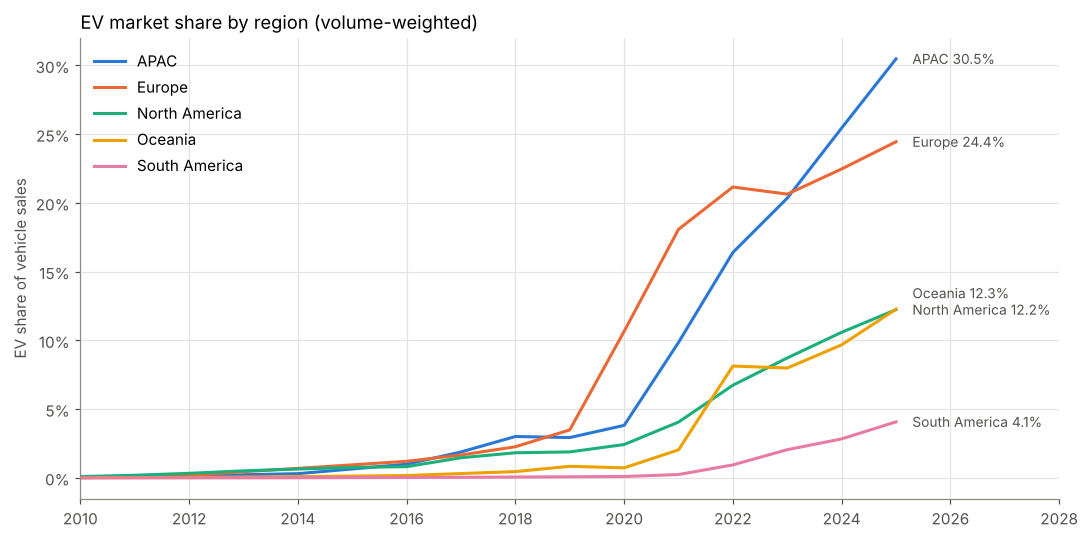

region,APAC,Europe,North America,Oceania,South America
year,,,,,
2015,0.650,0.950,0.760,0.130,0.020
2019,2.930,3.490,1.890,0.840,0.080
2020,3.820,10.660,2.430,0.730,0.100
2021,9.850,18.080,4.060,2.040,0.240
2025,30.480,24.450,12.240,12.270,4.080


In [22]:
region_year = df.groupby(["region", "year"], as_index=False)[["ev_sales", "ice_sales", "total_vehicle_sales"]].sum()
region_year["ev_market_share"] = region_year.ev_sales / region_year.total_vehicle_sales * 100
region_share = region_year.pivot(index="year", columns="region", values="ev_market_share")

fig, ax = plt.subplots(figsize=(10, 5))
for i, r in enumerate(region_share.columns):
    ax.plot(region_share.index, region_share[r], color=PALETTE[i], label=r)
end_labels(ax, [(f"{r} {region_share[r].iloc[-1]:.1f}%", region_share[r].iloc[-1], region_share.index[-1]) for r in region_share.columns], gap=1.2)
ax.set_title("EV market share by region (volume-weighted)", loc="left")
ax.set_ylabel("EV share of vehicle sales")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xlim(2010, 2028)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

region_share.loc[[2015, 2019, 2020, 2021, 2025]].round(2)

## 3.2 Country-level trends for 5 representative markets

In [23]:
# Country-year panel (volume-weighted share)
country_year = df.groupby(["country", "region", "year"], as_index=False)[["ev_sales", "ice_sales", "total_vehicle_sales"]].sum()
country_year["ev_market_share"] = country_year.ev_sales / country_year.total_vehicle_sales * 100

# Representative mix: share leader, volume leader, large mid-table market, two laggards
REP = ["Norway", "China", "United States", "Japan", "India"]
print(country_latest.set_index("country").loc[REP, ["region", "ev_market_share", "share_rank", "ev_sales", "volume_rank"]])

                      region  ev_market_share  share_rank  ev_sales  volume_rank
country                                                                         
Norway                Europe           79.961           1    125265           16
China                   APAC           41.229           3  12904603            1
United States  North America           12.552          15   2069197            2
Japan                   APAC            5.887          21    277344            7
India                   APAC            3.248          25    181269           10


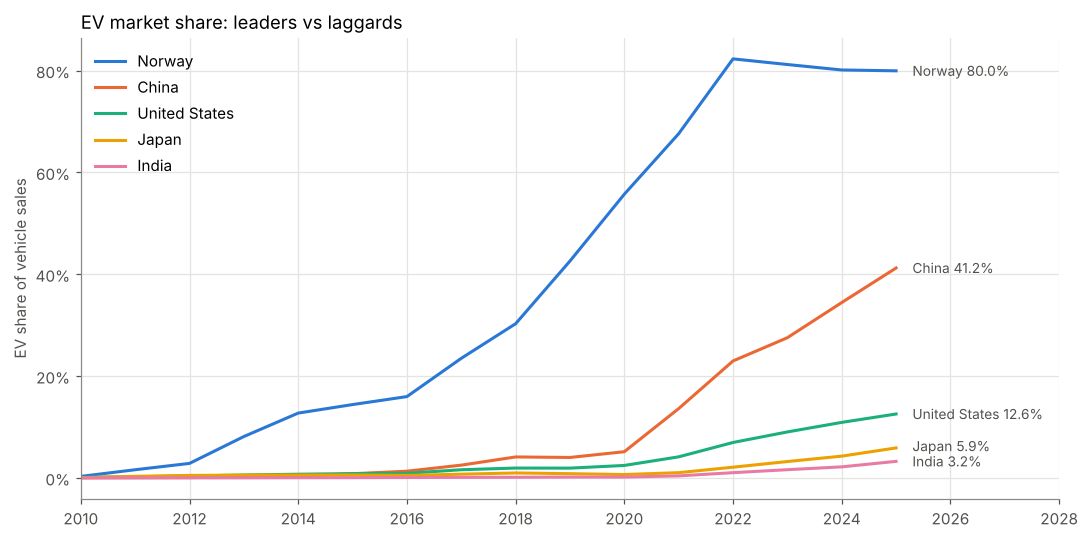

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
for i, c in enumerate(REP):
    s = country_year[country_year.country == c]
    ax.plot(s.year, s.ev_market_share, color=PALETTE[i], label=c)
last = country_year[country_year.year == LATEST].set_index("country").ev_market_share
end_labels(ax, [(f"{c} {last[c]:.1f}%", last[c], LATEST) for c in REP], gap=3)
ax.set_title("EV market share: leaders vs laggards", loc="left")
ax.set_ylabel("EV share of vehicle sales")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xlim(2010, 2028)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

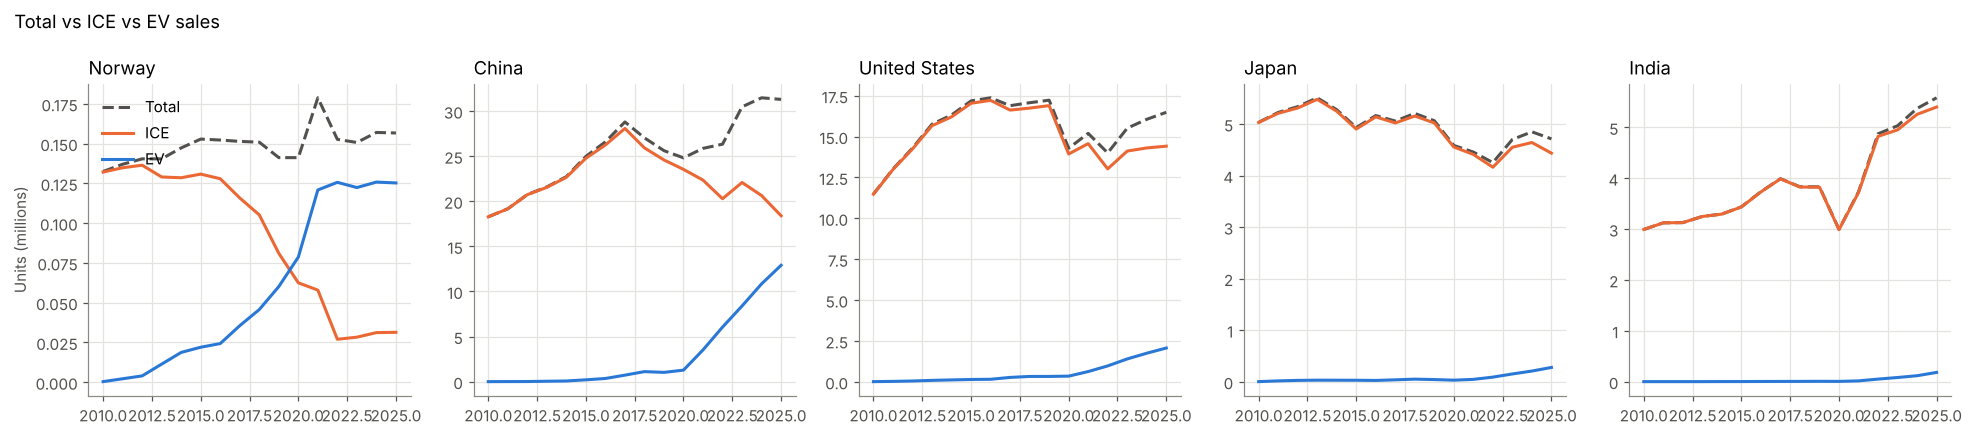

In [25]:
# Total vs EV vs ICE sales (small multiples, each country on its own scale)
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharex=True)
series = [("total_vehicle_sales", "Total", "#52514e"), ("ice_sales", "ICE", PALETTE[1]), ("ev_sales", "EV", PALETTE[0])]
for ax, c in zip(axes, REP):
    s = country_year[country_year.country == c]
    for col, lab, colr in series:
        ax.plot(s.year, s[col] / 1e6, color=colr, label=lab, linestyle="--" if col == "total_vehicle_sales" else "-")
    ax.set_title(c, loc="left")
    ax.set_ylabel("Units (millions)" if c == REP[0] else "")
axes[0].legend(loc="upper left")
fig.suptitle("Total vs ICE vs EV sales", x=0.01, ha="left")
plt.tight_layout()
plt.show()

In [26]:
# Does EV growth coincide with ICE decline? Compare ICE peak with 2025 level
ice_story = []
for c in REP:
    s = country_year[country_year.country == c].set_index("year")
    ice_story.append({
        "country": c,
        "ice_peak_year": s.ice_sales.idxmax(),
        "ice_change_peak_to_2025_%": (s.ice_sales.loc[LATEST] / s.ice_sales.max() - 1) * 100,
        "ev_change_2019_to_2025_x": s.ev_sales.loc[LATEST] / s.ev_sales.loc[2019],
        "total_change_2019_to_2025_%": (s.total_vehicle_sales.loc[LATEST] / s.total_vehicle_sales.loc[2019] - 1) * 100,
    })
ice_story = pd.DataFrame(ice_story)

# Correlation of yearly changes in EV and ICE sales (all countries, 2011+)
cy = country_year.sort_values(["country", "year"]).copy()
cy["d_ev"] = cy.groupby("country").ev_sales.diff()
cy["d_ice"] = cy.groupby("country").ice_sales.diff()
print("Corr(yearly change in EV sales, yearly change in ICE sales):", round(cy[["d_ev", "d_ice"]].corr().iloc[0, 1], 3))
ice_story

Corr(yearly change in EV sales, yearly change in ICE sales): -0.273


,country,ice_peak_year,ice_change_peak_to_2025_%,ev_change_2019_to_2025_x,total_change_2019_to_2025_%
0,Norway,2012,-76.987,2.083,10.967
1,China,2017,-34.487,12.551,22.199
2,United States,2016,-16.269,6.258,-4.302
3,Japan,2013,-19.056,6.585,-6.950
4,India,2025,0.000,29.134,45.703


## 3.3 Segment diffusion: does premium move first?

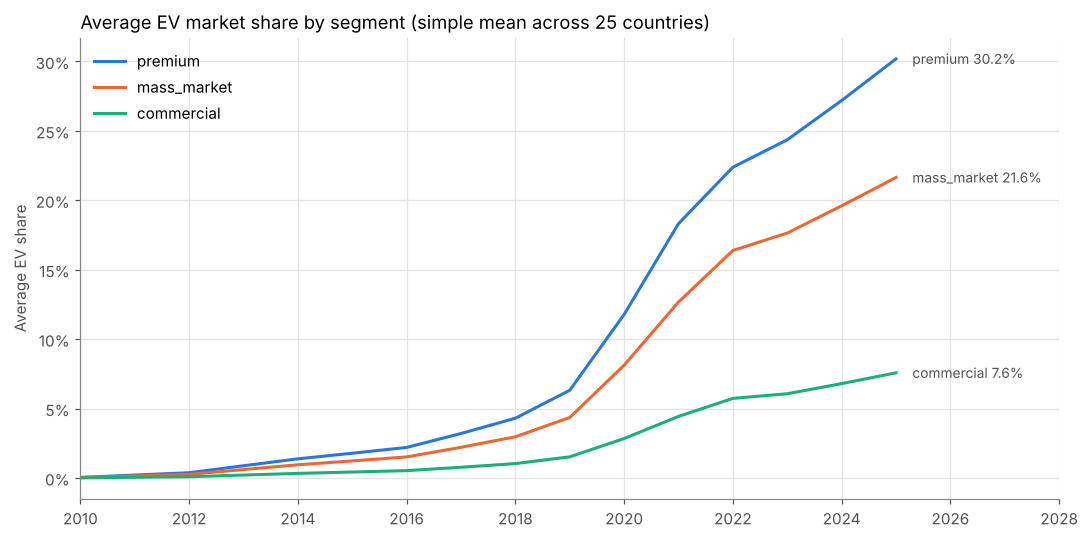

vehicle_segment,premium,mass_market,commercial
year,,,
2012,0.380,0.260,0.090
2015,1.780,1.230,0.430
2019,6.320,4.360,1.520
2020,11.780,8.120,2.840
2021,18.320,12.670,4.440
2025,30.190,21.640,7.580


In [27]:
seg_year = df.groupby(["vehicle_segment", "year"]).ev_market_share.mean().unstack(0)[["premium", "mass_market", "commercial"]]

fig, ax = plt.subplots(figsize=(10, 5))
for seg in seg_year.columns:
    ax.plot(seg_year.index, seg_year[seg], color=SEG_COLORS[seg], label=seg)
end_labels(ax, [(f"{g} {seg_year[g].iloc[-1]:.1f}%", seg_year[g].iloc[-1], LATEST) for g in seg_year.columns], gap=1.5)
ax.set_title("Average EV market share by segment (simple mean across 25 countries)", loc="left")
ax.set_ylabel("Average EV share")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xlim(2010, 2028)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()
seg_year.loc[[2012, 2015, 2019, 2020, 2021, 2025]].round(2)

In [28]:
# Timing test: first year each segment crosses 1%, 5%, 10%, 25% in each country
def first_year(s, thr):
    hit = s[s >= thr]
    return hit.index.min() if len(hit) else np.nan

timing = []
for (c, seg), g in df.groupby(["country", "vehicle_segment"]):
    s = g.set_index("year").ev_market_share
    for thr in [1, 5, 10, 25]:
        timing.append({"country": c, "segment": seg, "threshold": thr, "first_year": first_year(s, thr)})
timing = pd.DataFrame(timing)
tw = timing.pivot(index=["country", "threshold"], columns="segment", values="first_year")

# Lead of premium over mass market (years), only where both crossed
tw["premium_lead_vs_mass_yrs"] = tw.mass_market - tw.premium
tw["mass_lead_vs_commercial_yrs"] = tw.commercial - tw.mass_market
summary = tw.groupby("threshold").agg(
    median_year_premium=("premium", "median"),
    median_year_mass=("mass_market", "median"),
    median_year_commercial=("commercial", "median"),
    pct_premium_not_later=("premium_lead_vs_mass_yrs", lambda x: (x.dropna() >= 0).mean() * 100),
    pct_premium_strictly_first=("premium_lead_vs_mass_yrs", lambda x: (x.dropna() > 0).mean() * 100),
    avg_premium_lead_yrs=("premium_lead_vs_mass_yrs", "mean"),
    avg_mass_lead_over_commercial_yrs=("mass_lead_vs_commercial_yrs", "mean"),
    n_crossed_premium=("premium", "count"),
    n_crossed_mass=("mass_market", "count"),
    n_crossed_commercial=("commercial", "count"),
)
# Median years are among countries that crossed; counts show how many did
summary

,median_year_premium,median_year_mass,median_year_commercial,pct_premium_not_later,pct_premium_strictly_first,avg_premium_lead_yrs,avg_mass_lead_over_commercial_yrs,n_crossed_premium,n_crossed_mass,n_crossed_commercial
threshold,,,,,,,,,,
1,"2,017.000","2,017.000","2,020.000",100.000,60.000,0.840,2.240,25,25,25
5,"2,020.000","2,020.000","2,021.000",100.000,57.143,0.667,2.000,23,21,14
10,"2,020.500","2,020.000","2,022.000",100.000,47.368,0.842,3.000,20,19,5
25,"2,021.000","2,024.000","2,022.000",100.000,90.909,2.545,4.000,11,11,1


## 3.4 Fastest EV share acceleration

In [29]:
cy = country_year.sort_values(["country", "year"]).copy()
cy["share_yoy_pp"] = cy.groupby("country").ev_market_share.diff()

def slope(g, y0, y1):
    s = g[(g.year >= y0) & (g.year <= y1)]
    return np.polyfit(s.year, s.ev_market_share, 1)[0]

accel = []
for c, g in cy.groupby("country"):
    accel.append({
        "country": c,
        "share_2020": g.loc[g.year == 2020, "ev_market_share"].iloc[0],
        "share_2025": g.loc[g.year == LATEST, "ev_market_share"].iloc[0],
        "slope_2015_2019_pp_per_yr": slope(g, 2015, 2019),
        "slope_2020_2025_pp_per_yr": slope(g, 2020, 2025),
        "avg_yoy_pp_2021_2025": g.loc[g.year >= 2021, "share_yoy_pp"].mean(),
        "max_single_year_jump_pp": g.share_yoy_pp.max(),
        "max_jump_year": int(g.loc[g.share_yoy_pp.idxmax(), "year"]),
    })
accel = pd.DataFrame(accel)
accel["acceleration_pp"] = accel.slope_2020_2025_pp_per_yr - accel.slope_2015_2019_pp_per_yr
accel = accel.sort_values("slope_2020_2025_pp_per_yr", ascending=False).reset_index(drop=True)
accel.index = accel.index + 1
accel.head(8)

,country,share_2020,share_2025,slope_2015_2019_pp_per_yr,slope_2020_2025_pp_per_yr,avg_yoy_pp_2021_2025,max_single_year_jump_pp,max_jump_year,acceleration_pp
1,China,5.143,41.229,0.920,7.071,7.217,9.356,2022,6.151
2,Sweden,24.352,52.998,2.228,4.971,5.729,16.277,2021,2.743
3,Norway,55.725,79.961,7.071,4.504,4.847,14.700,2022,-2.567
4,Netherlands,19.485,37.146,2.181,4.126,3.532,9.344,2019,1.945
5,Switzerland,10.560,28.583,0.744,3.245,3.605,7.575,2021,2.501
6,Thailand,0.254,14.664,0.028,3.223,2.882,6.059,2023,3.195
7,Portugal,10.257,26.402,0.933,3.190,3.229,5.756,2020,2.258
8,Germany,13.337,32.473,0.605,3.119,3.827,13.105,2021,2.514


In [30]:
# Check that the ranking is robust across the three acceleration measures
for m in ["slope_2020_2025_pp_per_yr", "avg_yoy_pp_2021_2025", "acceleration_pp"]:
    print(f"{m:28s} top 3:", accel.nlargest(3, m).country.tolist())

slope_2020_2025_pp_per_yr    top 3: ['China', 'Sweden', 'Norway']
avg_yoy_pp_2021_2025         top 3: ['China', 'Sweden', 'Norway']
acceleration_pp              top 3: ['China', 'Thailand', 'Sweden']


## Key findings: EV diffusion story

**Who leads, who follows.** Europe and North America led through the mid 2010s. Europe broke away first, jumping from 3.5% (2019) to 10.7% (2020) and 18.1% (2021). APAC, driven by China's volume, accelerated from 2021 and overtook Europe in 2024 (25.5% vs 22.5%), reaching 30.5% in 2025. By 2025, North America (12.2%) and Oceania (12.3%) remain well below Europe (24.4%), while South America (4.1%) has the lowest regional EV share. Among the five representative countries, Norway (80.0%) and China (41.2%) lead, the US is mid-table (12.6%), and Japan (5.9%) and India (3.2%) lag.

**EV growth vs ICE decline.** EV growth is accompanied by ICE decline in several leading markets. Norway's ICE sales are 77% below their 2012 peak and China's are 34% below their 2017 peak, while total sales increased 11% and 22% from 2019 to 2025. The US and Japan also show ICE declines (16 to 19% below peak) alongside slightly smaller total markets, whereas India's ICE sales are at their sample-period peak in 2025. Across countries, yearly changes in EV and ICE sales are negatively correlated (r = -0.27). This pattern is consistent with partial substitution between EV and ICE sales, but the correlation alone does not establish that EV growth caused the ICE decline.

**Segment diffusion: premium leads, mass market follows, commercial trails.** Premium has the highest average share in every year (30.2% vs 21.6% mass market vs 7.6% commercial in 2025). Among countries where both premium and mass-market segments crossed a given threshold (1%, 5%, 10%, 25%), premium never crossed later than mass market and crossed strictly earlier in about 47% to 91% of cases, depending on the threshold. The lead is short at low thresholds (under 1 year) and widens to about 2.5 years at 25%. Commercial trails mass market by 2 to 4 years, and only 5 countries' commercial segments have reached 10% (only Norway has reached 25%). So the premium to mass-market path exists, but the segments rise together rather than in separate waves.

**Fastest share acceleration: China and Sweden.** Both rank #1 and #2 on the 2020 to 2025 slope (China 7.1 pp/yr, Sweden 5.0 pp/yr) and on average YoY change (7.2 and 5.7 pp/yr). China also has by far the largest acceleration versus 2015 to 2019 (+6.2 pp/yr), and Sweden is top 3 on all three measures. Norway is still growing (4.5 pp/yr) but more slowly than in 2015 to 2019 (7.1 pp/yr), so its acceleration is negative.

---
# 4. Driver Analysis: What Correlates With EV Market Share?

**Scope.** This task measures associations, not causal effects. The main ranking uses only the original dataset drivers.

**Supplementary proxy.** Raw `charging_stations` is heavily right-skewed and scales with market size, so one extra metric is reported as a robustness check: `chargers_per_1k_annual_sales` = charging stations per 1,000 vehicles sold in that country-year. This is **not** a true charging density (that would need population, vehicle stock or land area, which the dataset lacks). It also shares `total_vehicle_sales` as a denominator with EV market share, so part of its correlation with share can come from that shared denominator. It is therefore kept out of the main ranking.

## 4.1 Correlation view: overall and by segment

In [31]:
# Supplementary infrastructure features (not in the main ranking)
cy_total = df.groupby(["country", "year"]).total_vehicle_sales.transform("sum")
df["log_charging_stations"] = np.log1p(df.charging_stations)
df["chargers_per_1k_annual_sales"] = df.charging_stations / cy_total * 1000
PROXY = "chargers_per_1k_annual_sales"

# Row-level correlations (overall and within each segment)
corr_overall = pd.DataFrame({
    "pearson": df[DRIVERS].corrwith(df.ev_market_share),
    "spearman": df[DRIVERS].corrwith(df.ev_market_share, method="spearman"),
})
corr_seg = pd.DataFrame({seg: g[DRIVERS].corrwith(g.ev_market_share, method="spearman")
                         for seg, g in df.groupby("vehicle_segment")})
corr_seg.columns = [f"spearman_{c}" for c in corr_seg.columns]
corr_tbl = corr_overall.join(corr_seg).sort_values("spearman", ascending=False)
corr_tbl.round(3)

,pearson,spearman,spearman_commercial,spearman_mass_market,spearman_premium
charging_stations,0.214,0.870,0.889,0.891,0.890
emission_regulation_score,0.587,0.851,0.873,0.875,0.874
fast_chargers_share,0.459,0.769,0.783,0.786,0.786
fuel_price_usd_per_liter,0.554,0.617,0.636,0.635,0.635
gdp_per_capita,0.412,0.493,0.505,0.507,0.506
electricity_price_usd_per_kwh,0.215,0.407,0.415,0.415,0.414
ev_subsidy_usd,-0.056,0.302,0.296,0.301,0.300
urban_population_percent,0.176,0.271,0.275,0.278,0.278


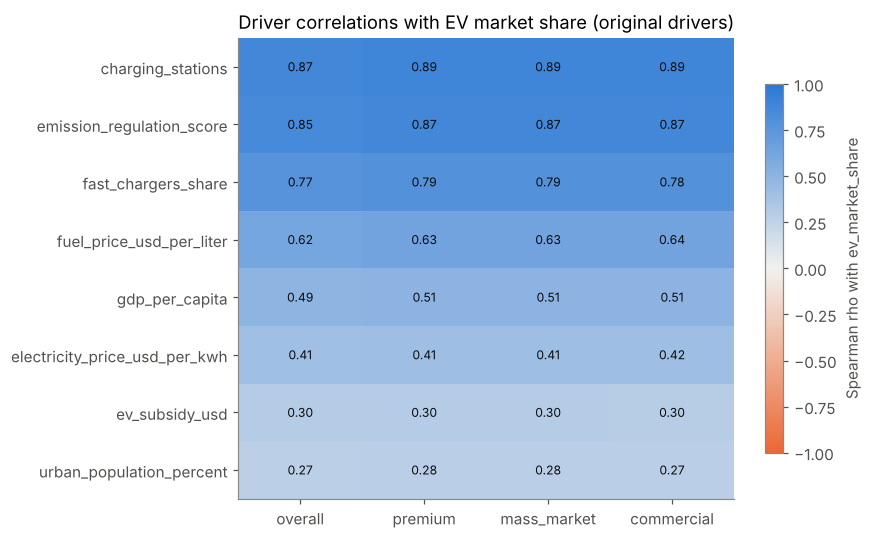

In [32]:
# Heatmap of Spearman correlations (diverging, neutral midpoint)
from matplotlib.colors import LinearSegmentedColormap
div = LinearSegmentedColormap.from_list("div", ["#eb6834", "#f2f1ee", "#2a78d6"])
hm = corr_tbl[["spearman", "spearman_premium", "spearman_mass_market", "spearman_commercial"]]

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(hm.values, cmap=div, vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(hm.shape[1]), ["overall", "premium", "mass_market", "commercial"])
ax.set_yticks(range(hm.shape[0]), hm.index)
ax.grid(False)
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        ax.text(j, i, f"{hm.values[i, j]:.2f}", ha="center", va="center", fontsize=8, color="#0b0b0b")
fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman rho with ev_market_share")
ax.set_title("Driver correlations with EV market share (original drivers)", loc="left")
plt.tight_layout()
plt.show()

## 4.2 Controls via grouping

Pooled correlations mix the common time trend (most drivers and EV share rise with `year`) with cross-country differences. Because drivers are country-year values, the controls are computed on a **country-year panel** (one row per country-year, share volume-weighted across segments), which avoids counting each driver value three times.
1. **Within year:** Spearman correlation inside each year, then averaged. This removes the common time trend.
2. **Within segment:** shown in 4.1.
3. **Within region:** Oceania and South America contain one country each, so their correlations are purely time-series and shown for completeness only.

In [33]:
# Country-year panel for driver analysis
cyp = df.groupby(["country", "region", "year"], as_index=False).agg(
    ev_sales=("ev_sales", "sum"), total_vehicle_sales=("total_vehicle_sales", "sum"),
    **{d: (d, "first") for d in DRIVERS})
cyp["ev_market_share"] = cyp.ev_sales / cyp.total_vehicle_sales * 100
cyp[PROXY] = cyp.charging_stations / cyp.total_vehicle_sales * 1000
ALLX = DRIVERS + [PROXY]

# Within-year correlations (cross-country, one year at a time)
within_year = pd.DataFrame({y: g[ALLX].corrwith(g.ev_market_share, method="spearman")
                            for y, g in cyp.groupby("year")})
within_region = pd.DataFrame({r: g[ALLX].corrwith(g.ev_market_share, method="spearman")
                              for r, g in cyp.groupby("region")})
ctrl = pd.DataFrame({
    "pooled_spearman": cyp[ALLX].corrwith(cyp.ev_market_share, method="spearman"),
    "within_year_mean": within_year.mean(axis=1),
    "within_year_2020_2025": within_year.loc[:, 2020:].mean(axis=1),
    "within_year_2025": within_year[LATEST],
    "corr_with_year": cyp[ALLX].corrwith(cyp.year, method="spearman"),
}).join(within_region.add_prefix("region_"))
ctrl.index = [f"{i} (supplementary proxy)" if i == PROXY else i for i in ctrl.index]
ctrl.sort_values("within_year_mean", ascending=False).round(2)

,pooled_spearman,within_year_mean,within_year_2020_2025,within_year_2025,corr_with_year,region_APAC,region_Europe,region_North America,region_Oceania,region_South America
chargers_per_1k_annual_sales (supplementary proxy),0.960,0.880,0.890,0.880,0.730,0.980,0.960,0.960,0.990,1.000
emission_regulation_score,0.870,0.870,0.920,0.890,0.540,0.910,0.930,0.940,0.990,0.990
charging_stations,0.890,0.720,0.600,0.520,0.740,0.920,0.900,0.940,0.990,1.000
gdp_per_capita,0.510,0.710,0.680,0.650,0.110,0.510,0.530,0.740,0.850,-0.390
fuel_price_usd_per_liter,0.630,0.640,0.780,0.700,0.340,0.660,0.740,0.590,0.740,0.420
fast_chargers_share,0.790,0.390,0.090,-0.060,0.830,0.950,0.890,0.920,0.990,1.000
electricity_price_usd_per_kwh,0.410,0.360,0.450,0.340,0.250,0.620,0.310,0.750,0.990,-0.420
urban_population_percent,0.280,0.360,0.290,0.290,0.110,0.480,0.340,0.890,-0.760,0.980
ev_subsidy_usd,0.300,0.270,0.010,-0.340,0.190,0.520,0.160,0.540,0.820,NaN


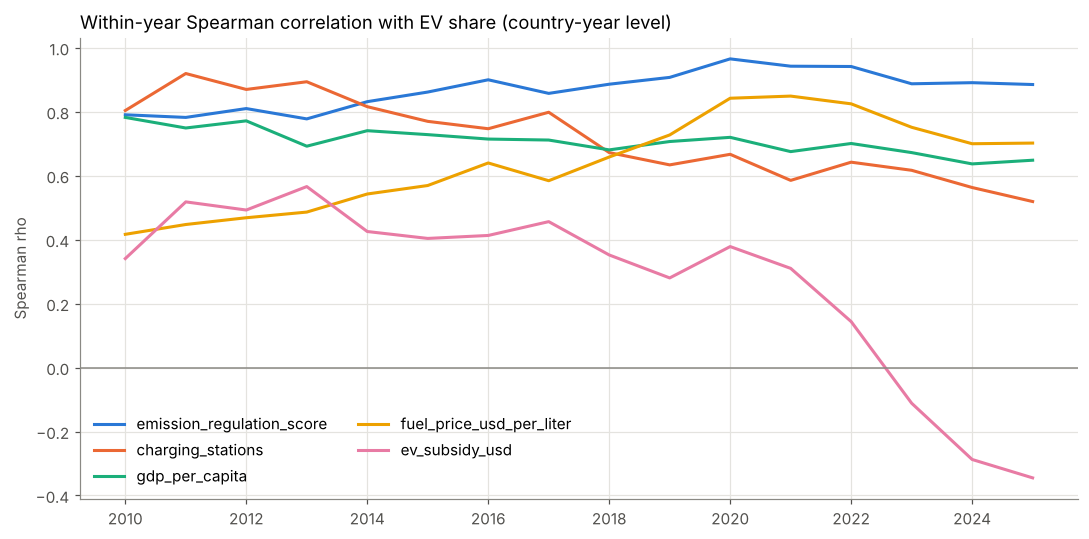

In [34]:
# How the cross-country signal for each driver evolves over time
fig, ax = plt.subplots(figsize=(10, 5))
show = ["emission_regulation_score", "charging_stations", "gdp_per_capita", "fuel_price_usd_per_liter", "ev_subsidy_usd"]
for i, d in enumerate(show):
    ax.plot(within_year.columns, within_year.loc[d], color=PALETTE[i], label=d)
ax.axhline(0, color="#8a8984", linewidth=1)
ax.set_title("Within-year Spearman correlation with EV share (country-year level)", loc="left")
ax.set_ylabel("Spearman rho")
ax.legend(loc="lower left", ncol=2)
plt.tight_layout()
plt.show()

## 4.3 Scatter plots with trend lines

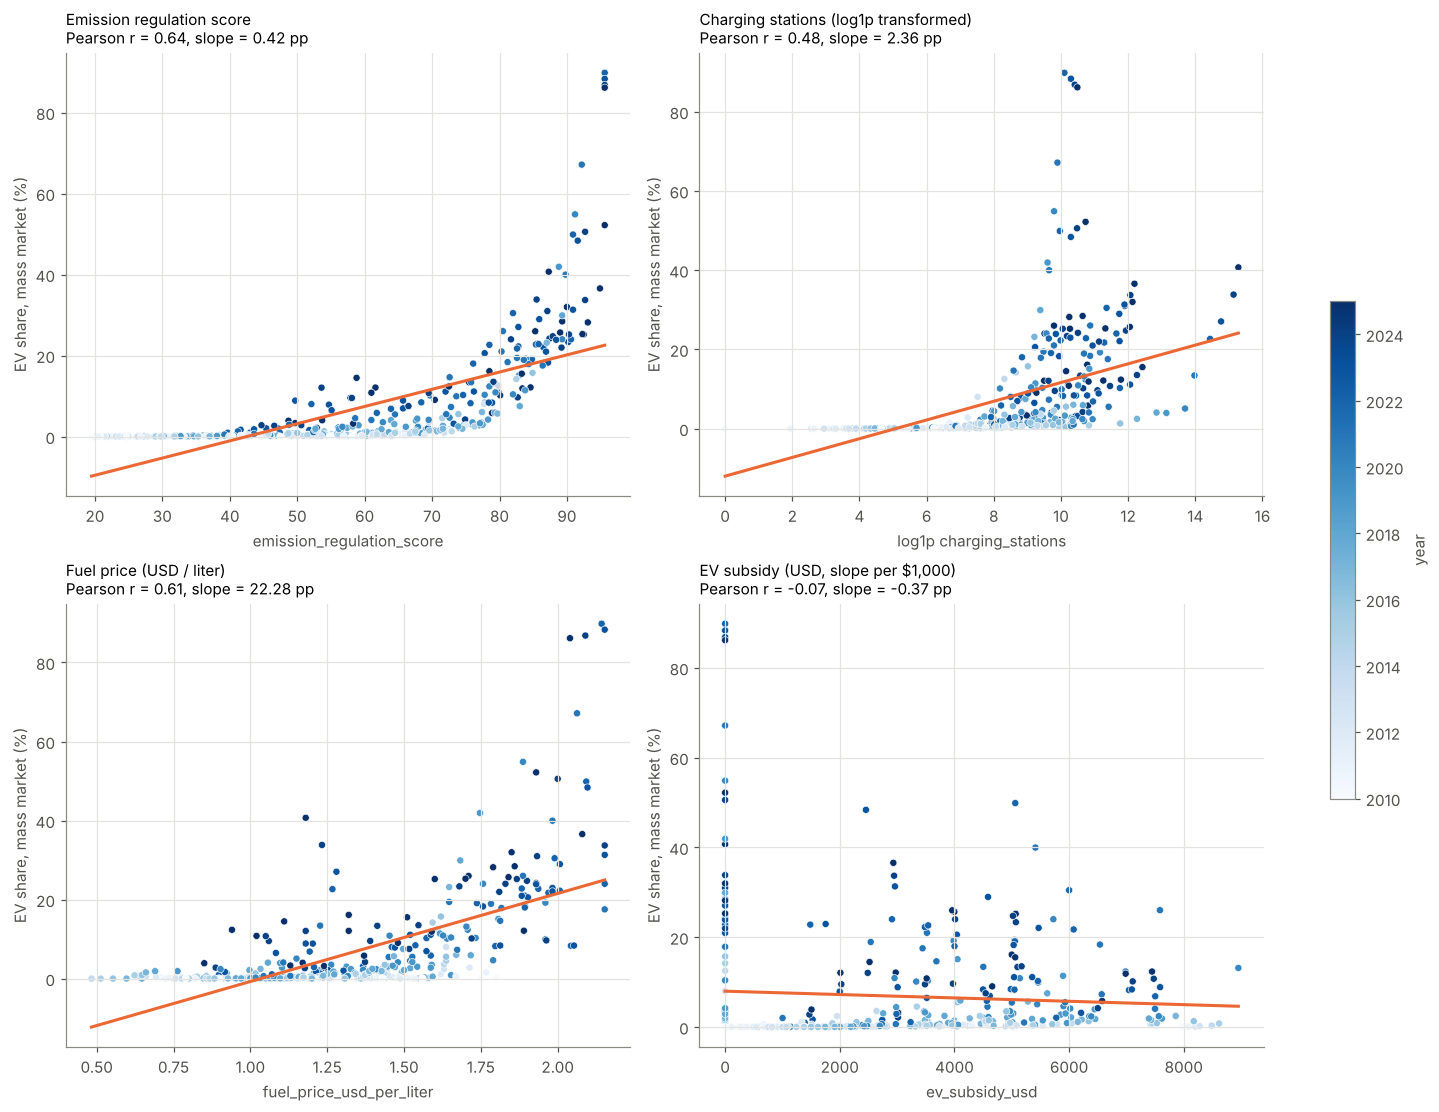

In [35]:
# Mass-market segment only, so each point is one country-year (drivers are country-year values)
mm = df[df.vehicle_segment == "mass_market"].copy()
plots = [
    ("emission_regulation_score", "Emission regulation score", False),
    ("charging_stations", "Charging stations (log1p transformed)", True),
    ("fuel_price_usd_per_liter", "Fuel price (USD / liter)", False),
    ("ev_subsidy_usd", "EV subsidy (USD, slope per $1,000)", False),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
for ax, (col, lab, logx) in zip(axes.ravel(), plots):
    x = mm[col].copy()
    # log1p keeps zero-station years, matching the regression transform
    ok = x.notna()
    xp = np.log1p(x[ok]) if logx else x[ok]
    y = mm.loc[ok, "ev_market_share"]
    sc = ax.scatter(xp, y, c=mm.loc[ok, "year"], cmap="Blues", s=22, edgecolor="white", linewidth=0.4)
    b1, b0 = np.polyfit(xp, y, 1)
    xs = np.linspace(xp.min(), xp.max(), 100)
    ax.plot(xs, b0 + b1 * xs, color=PALETTE[1])
    r = np.corrcoef(xp, y)[0, 1]
    shown = b1 * 1000 if col == "ev_subsidy_usd" else b1
    ax.set_title(f"{lab}\nPearson r = {r:.2f}, slope = {shown:.2f} pp", loc="left", fontsize=10)
    ax.set_xlabel(("log1p " if logx else "") + col)
    ax.set_ylabel("EV share, mass market (%)")
fig.colorbar(sc, ax=axes, shrink=0.5, label="year")
plt.show()

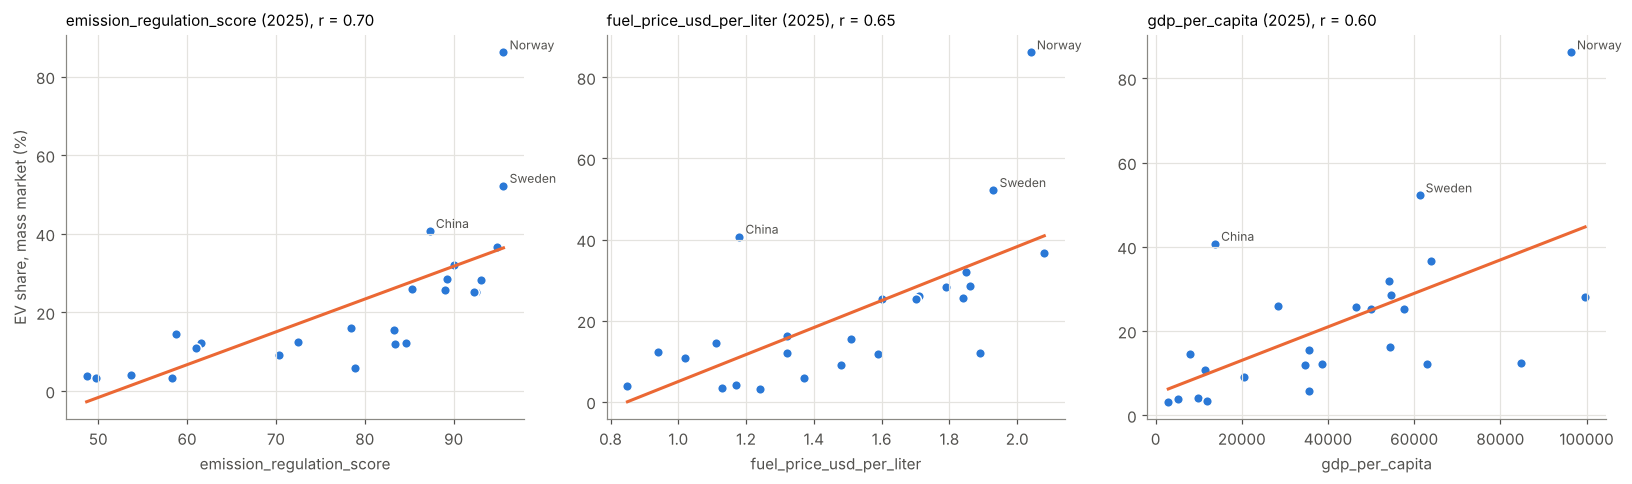

In [36]:
# Same relationships within the latest year only (pure cross-country view)
m25 = mm[mm.year == LATEST]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ["emission_regulation_score", "fuel_price_usd_per_liter", "gdp_per_capita"]):
    ax.scatter(m25[col], m25.ev_market_share, color=PALETTE[0], s=40, edgecolor="white")
    b1, b0 = np.polyfit(m25[col], m25.ev_market_share, 1)
    xs = np.linspace(m25[col].min(), m25[col].max(), 50)
    ax.plot(xs, b0 + b1 * xs, color=PALETTE[1])
    for _, rr in m25.nlargest(3, "ev_market_share").iterrows():
        ax.annotate(rr.country, (rr[col], rr.ev_market_share), xytext=(4, 2), textcoords="offset points", fontsize=8, color="#52514e")
    ax.set_title(f"{col} ({LATEST}), r = {m25[[col, 'ev_market_share']].corr().iloc[0, 1]:.2f}", loc="left", fontsize=10)
    ax.set_xlabel(col)
axes[0].set_ylabel("EV share, mass market (%)")
plt.tight_layout()
plt.show()

## 4.4 Modeling setup: unit of analysis and outcome scale

The correlations above describe one driver at a time. The models below estimate the drivers jointly, so each coefficient is conditional on the others.

**Unit of analysis.** Section 1 showed that every driver takes a single value per country-year, repeated across the three vehicle segments. Fitting a regression on the 1,200 segment rows would count each driver value three times and overstate how much independent information the data contain. The models therefore use the country-year panel `cyp` built in 4.2: 25 countries x 16 years = 400 observations, with EV share volume-weighted across segments. The panel is balanced, which matters for the variance decomposition in 4.7.

**Why transform EV market share?** EV share is bounded between 0 and 1, and at country-year level it is strongly right-skewed: most observations sit in the early diffusion stage near zero, while a few markets are past 50%. Adoption follows an S-shaped diffusion path, so a one-point change means something very different at 1% than at 50%. A linear model on the raw share forces the same absolute effect across that whole range.

The models instead use the log-odds of EV share, `logit(p) = ln(p / (1 - p))`. This is **OLS with a logit-transformed outcome**, not a logistic regression: the outcome is a continuous market share, not a binary label. Each coefficient is the change in the log-odds of EV share per one standard deviation of the driver, and `exp(coef)` is the corresponding multiplicative change in the odds.

The logit is undefined at exactly 0 or 1. The check below confirms that no country-year has zero EV sales or a 100% share, so no clipping or adjustment is needed. (This holds after aggregating to country-year level; some individual segment rows are close to zero.)

In [37]:
# Modeling frame: one row per country-year, built from the cyp panel in 4.2
mf = cyp.copy().sort_values(["country", "year"]).reset_index(drop=True)
share = mf.ev_sales / mf.total_vehicle_sales

# The logit is only defined strictly inside (0, 1)
assert (share > 0).all() and (share < 1).all(), "EV share hits 0 or 1; the logit needs an explicit adjustment"
mf["logit_share"] = np.log(share / (1 - share))

# Skewed station counts enter in logs, matching the earlier scatter plots
mf["log_charging_stations"] = np.log1p(mf.charging_stations)
mf["log_proxy"] = np.log1p(mf[PROXY])

# Standardize drivers so coefficients are per 1 SD and comparable across drivers
MODEL_X = ["log_charging_stations", "fast_chargers_share", "fuel_price_usd_per_liter", "electricity_price_usd_per_kwh",
           "ev_subsidy_usd", "emission_regulation_score", "gdp_per_capita", "urban_population_percent"]
for c in MODEL_X + ["log_proxy"]:
    mf[c] = (mf[c] - mf[c].mean()) / mf[c].std()

print(f"Country-years: {len(mf)} | countries: {mf.country.nunique()} | years: {mf.year.nunique()}")
print(f"Smallest EV share: {share.min():.6%} | largest: {share.max():.1%}")
pd.DataFrame({
    "ev_share_%": mf.ev_market_share.describe(),
    "logit_share": mf.logit_share.describe(),
}).T.assign(skew=[mf.ev_market_share.skew(), mf.logit_share.skew()])

Country-years: 400 | countries: 25 | years: 16
Smallest EV share: 0.000855% | largest: 82.3%


,count,mean,std,min,25%,50%,75%,max,skew
ev_share_%,400.000,6.920,12.953,0.001,0.101,0.995,8.389,82.307,3.118
logit_share,400.000,-4.767,2.801,-11.670,-6.893,-4.600,-2.391,1.537,-0.180


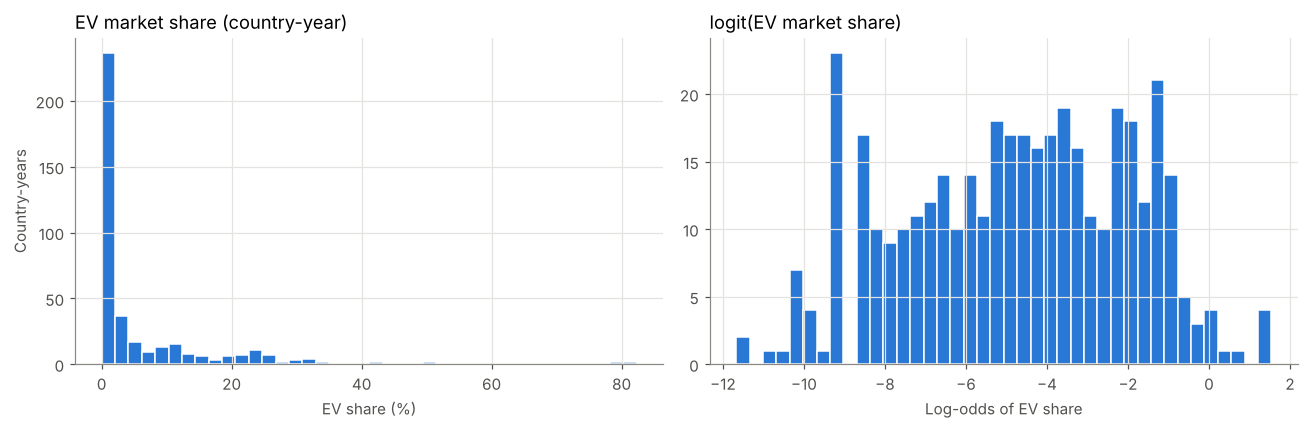

In [38]:
# Distribution of the outcome on both scales
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(mf.ev_market_share, bins=40, color=PALETTE[0], edgecolor="white")
axes[0].set_title("EV market share (country-year)", loc="left")
axes[0].set_xlabel("EV share (%)")
axes[0].set_ylabel("Country-years")
axes[1].hist(mf.logit_share, bins=40, color=PALETTE[0], edgecolor="white")
axes[1].set_title("logit(EV market share)", loc="left")
axes[1].set_xlabel("Log-odds of EV share")
plt.tight_layout()
plt.show()

On the raw scale the distribution is piled up near zero with a long right tail. On the logit scale it is roughly symmetric, which makes a linear model on this outcome far more reasonable.

## 4.5 Main model: logit EV share with year fixed effects

```
logit(EV share)_it = drivers_it + year fixed effects + error_it
```

- **Year fixed effects** absorb anything shared by all countries in a given year, such as battery cost declines, global model availability and the overall upward trend in adoption.
- **No country fixed effects in the main model.** With year effects only, the coefficients are identified mainly from **cross-country variation within each year**: whether countries with higher regulation scores than their peers in the same year also have higher EV share. This is the same comparison as the within-year Spearman correlations in 4.2, now estimated with all drivers together. Section 4.7 explains why country fixed effects are used as a robustness check rather than in the main model.
- **Standard errors are clustered by country**, because the 16 yearly observations of one country are not independent of each other.

The coefficients describe conditional associations in this panel. They are not causal effects of changing any driver.

In [39]:
def fit_logit(xs, fe="C(year)", data=mf, y="logit_share"):
    formula = f"{y} ~ {' + '.join(xs)} + {fe}"
    return smf.ols(formula, data=data).fit(cov_type="cluster", cov_kwds={"groups": data.country})

main = fit_logit(MODEL_X)

main_tbl = pd.DataFrame({
    "coef_log_odds_per_SD": main.params[MODEL_X],
    "cluster_SE": main.bse[MODEL_X],
    "cluster_p": main.pvalues[MODEL_X],
    "odds_ratio_per_SD": np.exp(main.params[MODEL_X]),
})
print(f"n = {int(main.nobs)} | R2 = {main.rsquared:.3f} | clusters = {mf.country.nunique()}")
main_tbl.sort_values("coef_log_odds_per_SD", key=abs, ascending=False).round(3)

n = 400 | R2 = 0.947 | clusters = 25


,coef_log_odds_per_SD,cluster_SE,cluster_p,odds_ratio_per_SD
emission_regulation_score,1.285,0.261,0.000,3.613
log_charging_stations,0.607,0.188,0.001,1.835
gdp_per_capita,0.374,0.171,0.029,1.454
electricity_price_usd_per_kwh,-0.302,0.115,0.009,0.739
urban_population_percent,-0.066,0.084,0.429,0.936
fuel_price_usd_per_liter,0.059,0.183,0.746,1.061
fast_chargers_share,-0.023,0.166,0.891,0.978
ev_subsidy_usd,0.016,0.086,0.856,1.016


**Functional-form check.** As a comparison, the same specification is fitted to the raw share. R-squared values are not comparable across different outcome scales, so the check uses residual patterns instead. A well-specified model should show residuals scattered evenly around zero across the fitted range.

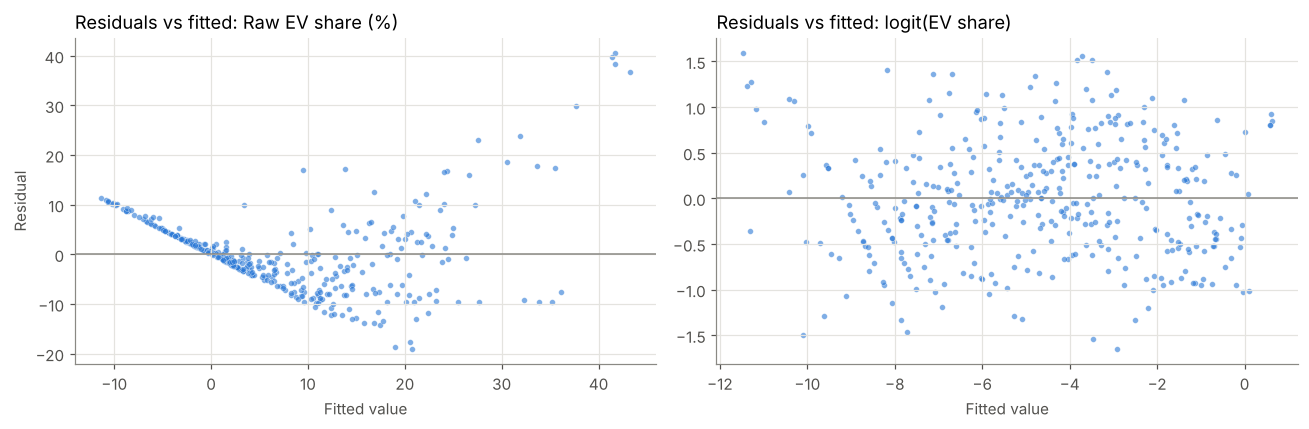

In [40]:
# Same drivers and year effects, outcome on the raw percentage scale
linear = fit_logit(MODEL_X, y="ev_market_share")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, m, title in [(axes[0], linear, "Raw EV share (%)"), (axes[1], main, "logit(EV share)")]:
    ax.scatter(m.fittedvalues, m.resid, s=14, color=PALETTE[0], alpha=0.6, edgecolor="white", linewidth=0.3)
    ax.axhline(0, color="#8a8984", linewidth=1)
    ax.set_title(f"Residuals vs fitted: {title}", loc="left")
    ax.set_xlabel("Fitted value")
axes[0].set_ylabel("Residual")
plt.tight_layout()
plt.show()

The raw-share model predicts negative shares for many early observations and its residual spread grows sharply with the fitted value, which is the pattern expected when an S-shaped process is forced into a straight line. The logit model's residuals are much more even across the range.

Under the logit specification, emission regulation and charging stations both have positive and statistically significant coefficients, even though they are highly correlated with each other (see 4.8). GDP per capita is positive and electricity price is negative. Fuel price is borderline significant (p = 0.05) in the same specification on the raw share scale, but close to zero once the outcome is modeled on the log-odds scale.

## 4.6 Small-cluster inference: wild cluster bootstrap

Cluster-robust standard errors rely on having many clusters. With only 25 countries, they tend to be too small, so p-values can look more convincing than the data support.

The **wild cluster bootstrap** addresses this. For each driver it imposes the null hypothesis that the coefficient is zero, refits the restricted model, and then generates bootstrap samples by flipping the sign and scale of each country's residuals as a block. The test statistic from the real data is compared with the distribution of test statistics from the 1,999 bootstrap samples. **Webb six-point weights** are used instead of the simpler two-point (Rademacher) weights because they produce a smoother bootstrap distribution when the number of clusters is limited.

The implementation below uses plain NumPy. Its cluster-robust t-statistics are checked against the `statsmodels` output before bootstrapping.

In [41]:
import patsy

# Design matrix identical to the main model
y_df, X_df = patsy.dmatrices("logit_share ~ " + " + ".join(MODEL_X) + " + C(year)", mf, return_type="dataframe")
X_mat, y_vec, x_cols = X_df.values, y_df.values.ravel(), list(X_df.columns)
groups = pd.factorize(mf.country)[0]
n_groups = groups.max() + 1

def cluster_t(X, y, j):
    # OLS coefficient j divided by its CR1 cluster-robust standard error (same correction as statsmodels)
    XtX_inv = np.linalg.inv(X.T @ X)
    b = XtX_inv @ X.T @ y
    u = y - X @ b
    n, k = X.shape
    meat = np.zeros((k, k))
    for g in range(n_groups):
        s = X[groups == g].T @ u[groups == g]
        meat += np.outer(s, s)
    V = XtX_inv @ meat @ XtX_inv * (n_groups / (n_groups - 1)) * ((n - 1) / (n - k))
    return b[j] / np.sqrt(V[j, j])

WEBB = np.array([-np.sqrt(1.5), -1, -np.sqrt(0.5), np.sqrt(0.5), 1, np.sqrt(1.5)])

def wild_cluster_bootstrap_p(var, B=1999, seed=42):
    j = x_cols.index(var)
    t_obs = cluster_t(X_mat, y_vec, j)
    # Restricted model: drop the tested variable to impose coefficient = 0
    X_r = np.delete(X_mat, j, axis=1)
    fitted_r = X_r @ np.linalg.lstsq(X_r, y_vec, rcond=None)[0]
    resid_r = y_vec - fitted_r
    rng = np.random.default_rng(seed)
    t_boot = np.empty(B)
    for b in range(B):
        # One weight per country, applied to all of that country's residuals
        w = rng.choice(WEBB, n_groups)[groups]
        t_boot[b] = cluster_t(X_mat, fitted_r + resid_r * w, j)
    return t_obs, np.mean(np.abs(t_boot) >= abs(t_obs))

# Sanity check: NumPy t-statistics must match statsmodels
assert np.allclose([cluster_t(X_mat, y_vec, x_cols.index(v)) for v in MODEL_X], main.tvalues[MODEL_X].values)

wcb = pd.DataFrame([(v, *wild_cluster_bootstrap_p(v)) for v in MODEL_X], columns=["driver", "t_stat", "wcb_p"]).set_index("driver")
wcb["coef"] = main.params[MODEL_X]
wcb["cluster_p"] = main.pvalues[MODEL_X]

def verdict(row):
    if row.cluster_p < 0.05 and row.wcb_p < 0.05:
        return "Robust"
    if row.cluster_p < 0.05:
        return "Not robust after small-cluster correction"
    return "Not significant"

wcb["interpretation"] = wcb.apply(verdict, axis=1)
wcb[["coef", "cluster_p", "wcb_p", "interpretation"]].sort_values("wcb_p").round(3)

,coef,cluster_p,wcb_p,interpretation
driver,,,,
emission_regulation_score,1.285,0.000,0.000,Robust
log_charging_stations,0.607,0.001,0.011,Robust
electricity_price_usd_per_kwh,-0.302,0.009,0.062,Not robust after small-cluster correction
gdp_per_capita,0.374,0.029,0.176,Not robust after small-cluster correction
urban_population_percent,-0.066,0.429,0.478,Not significant
fuel_price_usd_per_liter,0.059,0.746,0.770,Not significant
ev_subsidy_usd,0.016,0.856,0.870,Not significant
fast_chargers_share,-0.023,0.891,0.917,Not significant


Regulation and charging stations remain significant under the bootstrap. Electricity price and GDP per capita are significant with ordinary clustered standard errors but not after the small-cluster correction, so the evidence for them is weaker than the first table suggests. With 25 clusters, the bootstrap p-values are the more reliable guide.

## 4.7 Where the identifying variation comes from

**Why examine within-country variation?** A common next step would be to add country fixed effects, which control for every stable difference between countries (consumer preferences, energy mix, geography). Fixed-effects estimates rely only on changes **within** countries over time. Before treating a two-way fixed-effects (TWFE) model as the primary specification, it is worth checking how much variation remains once country and year means are removed.

The table reports, for each variable, the share of its total variance that is left:
- after removing country means (`within_country`), and
- after removing both country and year means (`within_country_and_year`), which is the only variation a TWFE model can use.

In [42]:
def residual_variance_share(col, by_year):
    s = mf[col]
    r = s - mf.groupby("country")[col].transform("mean")
    if by_year:
        # Balanced panel, so subtracting country and year means and adding back the grand mean is exact two-way demeaning
        r = r - mf.groupby("year")[col].transform("mean") + s.mean()
    return r.var() / s.var()

variance_tbl = pd.DataFrame({
    "within_country": [residual_variance_share(c, False) for c in MODEL_X + ["logit_share"]],
    "within_country_and_year": [residual_variance_share(c, True) for c in MODEL_X + ["logit_share"]],
}, index=MODEL_X + ["logit_share"])
variance_tbl.sort_values("within_country_and_year").round(3)

,within_country,within_country_and_year
urban_population_percent,0.015,0.008
emission_regulation_score,0.317,0.013
gdp_per_capita,0.034,0.018
logit_share,0.684,0.044
log_charging_stations,0.594,0.047
electricity_price_usd_per_kwh,0.142,0.062
fast_chargers_share,0.670,0.063
fuel_price_usd_per_liter,0.277,0.063
ev_subsidy_usd,0.354,0.273


Most of the variation in the drivers is **between countries**, not within countries over time. After removing country and year means, only about 1% of the variance in emission regulation, GDP per capita and urban population remains, and roughly 5% to 6% for charging stations and prices. Subsidy is the exception, with about a quarter of its variance remaining, because subsidy programs are switched on, changed and withdrawn within countries.

This means a TWFE model has very limited information to estimate the regulation, GDP and urban coefficients, and its estimates for those drivers will be imprecise and sensitive to noise. TWFE is therefore treated as a **robustness specification rather than the primary model**: it answers the narrower question of whether within-country changes line up with within-country changes in adoption.

In [43]:
twfe = fit_logit(MODEL_X, fe="C(country) + C(year)")

twfe_tbl = pd.DataFrame({
    "main_coef": main.params[MODEL_X], "main_p": main.pvalues[MODEL_X],
    "twfe_coef": twfe.params[MODEL_X], "twfe_p": twfe.pvalues[MODEL_X],
    "within_variance_share": variance_tbl.loc[MODEL_X, "within_country_and_year"],
})
twfe_tbl.round(3)

,main_coef,main_p,twfe_coef,twfe_p,within_variance_share
log_charging_stations,0.607,0.001,0.893,0.034,0.047
fast_chargers_share,-0.023,0.891,0.334,0.110,0.063
fuel_price_usd_per_liter,0.059,0.746,-0.052,0.844,0.063
electricity_price_usd_per_kwh,-0.302,0.009,0.285,0.237,0.062
ev_subsidy_usd,0.016,0.856,0.243,0.000,0.273
emission_regulation_score,1.285,0.000,1.064,0.006,0.013
gdp_per_capita,0.374,0.029,-0.380,0.528,0.018
urban_population_percent,-0.066,0.429,0.276,0.663,0.008


Regulation and charging stations keep positive, significant coefficients even within countries, so their association with adoption is not only a cross-country pattern. Electricity price and GDP per capita lose significance and both change sign, which fits their very small within-country variation. Subsidy becomes positive and significant: years in which a country's subsidy is higher than usual for that country tend to have higher EV share than usual. Because subsidy is the driver with the most within-country variation, this is the comparison where TWFE adds the most information, though it remains an association, and the subsidy result does not hold in the cross-country model.

## 4.8 Multicollinearity: regulation and charging

Regulation and charging availability tend to rise together. When two predictors are highly correlated, the model has difficulty attributing the shared variation to either one, and their individual coefficients can become unstable. Variance inflation factors (VIF) measure how much each coefficient's variance is inflated by correlation with the other drivers. The exclusion models then refit the main specification without one of the two variables to see how the other coefficient responds.

In [44]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF on the country-year drivers (constant added for a centered VIF)
X_vif = mf[MODEL_X].assign(const=1.0)
vif = pd.Series([variance_inflation_factor(X_vif.values, i) for i in range(len(MODEL_X))], index=MODEL_X, name="VIF")
print("Corr(log charging stations, regulation score):",
      round(mf[["log_charging_stations", "emission_regulation_score"]].corr().iloc[0, 1], 3))
vif.sort_values(ascending=False).round(2)

Corr(log charging stations, regulation score): 0.79


emission_regulation_score       11.520
log_charging_stations            7.760
fuel_price_usd_per_liter         4.970
fast_chargers_share              3.890
gdp_per_capita                   2.630
electricity_price_usd_per_kwh    2.170
ev_subsidy_usd                   1.650
urban_population_percent         1.500
Name: VIF, dtype: float64

In [45]:
# Refit the main model with and without each of the two collinear drivers
PAIR = ["log_charging_stations", "emission_regulation_score"]
exclusion = {
    "Full model": fit_logit(MODEL_X),
    "Drop regulation": fit_logit([c for c in MODEL_X if c != "emission_regulation_score"]),
    "Drop charging": fit_logit([c for c in MODEL_X if c != "log_charging_stations"]),
}
pd.DataFrame({
    name: {f"{v} coef": m.params.get(v, np.nan) for v in PAIR} | {f"{v} p": m.pvalues.get(v, np.nan) for v in PAIR}
    for name, m in exclusion.items()
}).round(3)

,Full model,Drop regulation,Drop charging
log_charging_stations coef,0.607,1.090,NaN
emission_regulation_score coef,1.285,NaN,1.587
log_charging_stations p,0.001,0.000,NaN
emission_regulation_score p,0.000,NaN,0.000


Regulation has a VIF above 10 and charging stations about 8, confirming substantial overlap. Even so, both coefficients stay positive and significant in the full model, and their signs do not change in either exclusion model. When one is dropped, the other coefficient grows, which is what happens when two variables share part of the same signal: the remaining variable absorbs the part it had been sharing. The two are best read as related parts of a common policy-and-infrastructure environment rather than as cleanly separable levers.

## 4.9 Robustness checks

The main model is refitted under several alternative specifications. A finding is treated as robust only if its sign and approximate size hold across them.

| Specification | What it tests |
|---|---|
| Region FE | Adds region fixed effects to absorb broad regional differences |
| Lagged drivers (t-1) | Uses the previous year's drivers. Drivers change slowly, so this is close to the main model and is a secondary check rather than evidence about timing or causality |
| 2010 to 2017 / 2018 to 2025 | Whether the associations come only from the early or the later phase of adoption |
| Drop share < 0.1% | Very small shares have extreme log-odds values (as low as about -11.7) and could carry too much weight on the logit scale |
| Charging proxy | Replaces log station count with the supplementary chargers-per-1,000-sales proxy introduced at the start of this section |
| TWFE | Country and year fixed effects, from 4.7 |

In [46]:
# Lagged drivers: previous year's value for the same country
lagged = mf.copy()
for c in MODEL_X:
    lagged[c] = lagged.groupby("country")[c].shift(1)
lagged = lagged.dropna(subset=MODEL_X)

PROXY_X = ["log_proxy"] + MODEL_X[1:]
robustness_models = {
    "Main": main,
    "Region FE": fit_logit(MODEL_X, fe="C(year) + C(region)"),
    "Lag t-1": fit_logit(MODEL_X, data=lagged),
    "2010-2017": fit_logit(MODEL_X, data=mf[mf.year <= 2017]),
    "2018-2025": fit_logit(MODEL_X, data=mf[mf.year >= 2018]),
    "Drop share < 0.1%": fit_logit(MODEL_X, data=mf[mf.ev_market_share >= 0.1]),
    "Charging proxy": fit_logit(PROXY_X),
    "TWFE": twfe,
}

def coef_with_stars(m, v):
    # Proxy specification reports the proxy in the charging row
    v = "log_proxy" if v == "log_charging_stations" and "log_proxy" in m.params else v
    b, p = m.params[v], m.pvalues[v]
    stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
    return f"{b:+.2f}{stars}"

robust_tbl = pd.DataFrame({name: [coef_with_stars(m, v) for v in MODEL_X] for name, m in robustness_models.items()}, index=MODEL_X)
robust_tbl.loc["n"] = [int(m.nobs) for m in robustness_models.values()]
print("Coefficients in log-odds per SD; country-clustered p-values: *** < 0.01, ** < 0.05, * < 0.10")
robust_tbl

Coefficients in log-odds per SD; country-clustered p-values: *** < 0.01, ** < 0.05, * < 0.10


,Main,Region FE,Lag t-1,2010-2017,2018-2025,Drop share < 0.1%,Charging proxy,TWFE
log_charging_stations,+0.61***,+0.54**,+0.69***,+1.03***,+0.28,+0.51**,+0.70***,+0.89**
fast_chargers_share,-0.02,-0.01,-0.14,-0.14,+0.12,+0.03,+0.17,+0.33
fuel_price_usd_per_liter,+0.06,+0.08,+0.03,-0.18,+0.33,+0.27,-0.10,-0.05
electricity_price_usd_per_kwh,-0.30***,-0.36***,-0.36***,-0.47***,-0.24**,-0.32***,-0.17,+0.28
ev_subsidy_usd,+0.02,+0.01,+0.02,-0.05,-0.04,-0.01,+0.18**,+0.24***
emission_regulation_score,+1.28***,+1.61***,+1.35***,+1.35***,+1.21***,+1.08***,+1.08***,+1.06***
gdp_per_capita,+0.37**,+0.14,+0.35*,+0.34,+0.29**,+0.31**,+0.38**,-0.38
urban_population_percent,-0.07,-0.11,-0.07,-0.03,-0.07,-0.01,-0.01,+0.28
n,400,400,375,200,200,301,400,400


- **Emission regulation** is positive and significant at the 1% level in every specification, including both periods, the lagged model and TWFE. It is the most stable result in the analysis.
- **Charging stations** are positive in every specification and significant in all but the 2018 to 2025 subsample, where the coefficient is smaller and imprecise. The association looks strongest in the early phase of adoption, when charging availability varied most across countries.
- **Electricity price** is negative in all cross-country specifications but turns positive and insignificant in TWFE, and it did not survive the wild cluster bootstrap. It is a plausible but weakly supported association.
- **GDP per capita** is positive in most specifications but often only marginally significant, and it reverses sign under TWFE.
- **Fuel price, fast-charger share and urban population** show no consistent association once the other drivers are controlled for.
- **Subsidy** is near zero across countries and is significant only in TWFE and in the proxy specification, so its relationship with adoption depends on which comparison is made.
- Dropping the 99 country-years with EV share below 0.1% leaves the main conclusions unchanged, so they are not driven by extreme log-odds values from the earliest years.

In [47]:
# Driver ranking: bivariate within-year association (4.2) next to the joint model results
reg_name = {d: ("log_charging_stations" if d == "charging_stations" else d) for d in DRIVERS}
rank_tbl = pd.DataFrame({
    "pooled_spearman": ctrl.pooled_spearman.reindex(DRIVERS),
    "within_year_spearman": ctrl.within_year_mean.reindex(DRIVERS),
    "main_coef": [main.params[reg_name[d]] for d in DRIVERS],
    "cluster_p": [main.pvalues[reg_name[d]] for d in DRIVERS],
    "wcb_p": [wcb.loc[reg_name[d], "wcb_p"] for d in DRIVERS],
    "twfe_coef": [twfe.params[reg_name[d]] for d in DRIVERS],
})
rank_tbl["rank"] = rank_tbl.within_year_spearman.rank(ascending=False).astype(int)
rank_tbl.sort_values("rank").round(3)

,pooled_spearman,within_year_spearman,main_coef,cluster_p,wcb_p,twfe_coef,rank
emission_regulation_score,0.875,0.870,1.285,0.000,0.000,1.064,1
charging_stations,0.890,0.720,0.607,0.001,0.011,0.893,2
gdp_per_capita,0.506,0.708,0.374,0.029,0.176,-0.380,3
fuel_price_usd_per_liter,0.634,0.638,0.059,0.746,0.770,-0.052,4
fast_chargers_share,0.786,0.389,-0.023,0.891,0.917,0.334,5
electricity_price_usd_per_kwh,0.414,0.362,-0.302,0.009,0.062,0.285,6
urban_population_percent,0.276,0.360,-0.066,0.429,0.478,0.276,7
ev_subsidy_usd,0.302,0.271,0.016,0.856,0.870,0.243,8


## Key findings: drivers of EV adoption

**Driver ranking.** Drivers are ordered by average within-year Spearman correlation (4.2), shown next to the joint model. Coefficients are changes in the log-odds of EV share per 1 SD of the driver, from the main model (logit outcome, year fixed effects, country-clustered errors). The bootstrap p-value is the wild cluster bootstrap from 4.6.

| Rank | Driver | Within-year rho | Main model coef | Bootstrap p | Across robustness checks |
|---|---|---|---|---|---|
| 1 | Emission regulation score | 0.87 | +1.28 | <0.001 | Positive and significant in every specification |
| 2 | Charging stations (log) | 0.72 | +0.61 | 0.011 | Positive throughout; significant except 2018 to 2025 |
| 3 | GDP per capita | 0.71 | +0.37 | 0.176 | Mostly positive, weak; reverses within countries |
| 4 | Fuel price | 0.64 | +0.06 | 0.770 | No consistent conditional association |
| 5 | Fast-charger share | 0.39 | -0.02 | 0.917 | No consistent conditional association |
| 6 | Electricity price | 0.36 | -0.30 | 0.062 | Negative across countries, not within countries |
| 7 | Urban population | 0.36 | -0.07 | 0.478 | No consistent conditional association |
| 8 | EV subsidy | 0.27 | +0.02 | 0.870 | Positive only within countries (TWFE) |

**What the joint model adds to the correlations**
- **Regulation and charging are the two robust associations.** They are the only drivers that remain significant after the small-cluster correction, and both stay positive within countries over time. They are highly collinear (r = 0.79, VIF 11.5 and 7.8), yet the data still support a positive association for each when they are estimated together.
- **Fuel price and GDP lose most of their signal once regulation and charging are controlled for.** Both have strong bivariate within-year correlations, but much of that overlaps with the regulation-and-charging environment. GDP is only weakly supported, and fuel price shows no conditional association.
- **Functional form matters.** On the raw share scale, regulation and charging look insignificant and fuel price looks like the main cost driver. The residual check in 4.5 shows that this specification does not fit the S-shaped adoption pattern, so the logit results are the ones carried forward.
- **Cross-country and within-country comparisons answer different questions.** Most driver variation is between countries (4.7), so the main model mainly describes which kinds of markets have higher adoption. The TWFE check shows that regulation, charging and subsidy changes also line up with adoption changes within countries, while electricity price and GDP do not.

**Why these drivers may matter** (interpretation, not tested causally by this dataset)
- **Regulation and charging availability describe a joint policy-and-infrastructure environment.** Stricter emission regulation and wider charging access tend to arrive together. Both are associated with higher adoption, and the data cannot cleanly separate how much each contributes.
- **Charging access may matter most early in diffusion.** The charging association is strongest in 2010 to 2017 and weaker after 2018, consistent with the idea that charging availability is a stronger barrier in the early stage of adoption. The dataset does not measure charging convenience directly.
- **Subsidies relate to adoption within countries rather than across them.** High-adoption markets do not have higher subsidies than their peers, but a country tends to see higher adoption in its own higher-subsidy years. This pattern is also consistent with subsidies being adjusted in response to adoption, so the direction of the relationship is not established.

**Limitations**
- All results are associations in observational data. None of the coefficients estimates the effect of changing a policy or price.
- With 25 country clusters, inference is limited even with the bootstrap correction.
- Several drivers vary very little within countries, so within-country estimates for them are imprecise.
- The model is designed for explanatory analysis rather than forecasting; modeling future adoption would require a dedicated diffusion or forecasting framework.
- The dataset was provided as part of the course materials; its original generation process and external provenance are not documented, so these results describe patterns in this panel and have not been validated against official vehicle registration data.

---
# 5. EV-Dominance Profiling (Market Classification)
## 5.1 Label and who is dominant

`is_ev_dominant` is used as the label. Section 1 confirmed it is exactly equivalent to `ev_market_share >= 50`.

In [48]:
assert (df.is_ev_dominant == (df.ev_market_share >= 50).astype(int)).all()
dom = df[df.is_ev_dominant == 1]
print("Dominant rows:", len(dom), "| countries:", sorted(dom.country.unique()))
dom.groupby(["country", "vehicle_segment"]).year.agg(first_dominant_year="min", n_years="count")

Dominant rows: 22 | countries: ['China', 'Netherlands', 'Norway', 'Sweden']


first_dominant_year  n_years
country     vehicle_segment                              
China       premium                         2025        1
Netherlands premium                         2025        1
Norway      mass_market                     2020        6
            premium                         2019        7
Sweden      mass_market                     2024        2
            premium                         2021        5

In [49]:
# Markets closest to dominance in the latest year (not yet dominant, share >= 30%)
near = snap[(snap.is_ev_dominant == 0) & (snap.ev_market_share >= 30)]
near[["country", "vehicle_segment", "ev_market_share", "ev_growth_rate_yoy"]].assign(
    gap_to_50_pp=lambda d: 50 - d.ev_market_share).sort_values("gap_to_50_pp")

,country,vehicle_segment,ev_market_share,ev_growth_rate_yoy,gap_to_50_pp
383,Germany,premium,46.370,7.830,3.630
143,Belgium,premium,41.220,17.100,8.780
1007,Switzerland,premium,40.860,15.630,9.140
271,China,mass_market,40.690,20.470,9.310
815,Portugal,premium,37.690,12.730,12.310
335,France,premium,37.240,10.310,12.760
1151,United Kingdom,premium,36.670,17.630,13.330
655,Netherlands,mass_market,36.570,12.290,13.430
95,Austria,premium,36.550,10.610,13.450
367,Germany,mass_market,31.980,6.540,18.020


## 5.2 Dominance signature

In [50]:
SIG = ["charging_stations", "chargers_per_1k_annual_sales", "fast_chargers_share", "ev_subsidy_usd", "emission_regulation_score",
       "fuel_price_usd_per_liter", "electricity_price_usd_per_kwh", "gdp_per_capita", "urban_population_percent"]

# Benchmark 1: all non-dominant rows. Benchmark 2: non-dominant rows in the same years (removes the time effect)
dom_years = dom.year.unique()
nondom_all = df[df.is_ev_dominant == 0]
nondom_same = nondom_all[nondom_all.year.isin(dom_years)]

signature = pd.DataFrame({
    "dominant_mean": dom[SIG].mean(),
    "non_dominant_mean_all_years": nondom_all[SIG].mean(),
    "non_dominant_mean_same_years": nondom_same[SIG].mean(),
})
signature["ratio_vs_same_years"] = signature.dominant_mean / signature.non_dominant_mean_same_years
print(f"Dominant n = {len(dom)}, non-dominant n = {len(nondom_all)} (same years n = {len(nondom_same)}), years {dom_years.min()} to {dom_years.max()}")
signature.round(3)

Dominant n = 22, non-dominant n = 1178 (same years n = 503), years 2019 to 2025


,dominant_mean,non_dominant_mean_all_years,non_dominant_mean_same_years,ratio_vs_same_years
charging_stations,"231,834.045","53,672.688","115,996.316",1.999
chargers_per_1k_annual_sales,162.112,20.939,42.368,3.826
fast_chargers_share,28.982,14.166,21.736,1.333
ev_subsidy_usd,721.045,"2,951.838","3,445.225",0.209
emission_regulation_score,93.251,58.118,68.770,1.356
fuel_price_usd_per_liter,1.991,1.330,1.492,1.334
electricity_price_usd_per_kwh,0.147,0.170,0.193,0.758
gdp_per_capita,"77,564.682","34,868.767","36,897.419",2.102
urban_population_percent,84.618,74.422,75.481,1.121


In [51]:
# Median comparison (robust to China's charging-station outlier) and percentile position of dominant rows
med = pd.DataFrame({"dominant_median": dom[SIG].median(), "non_dominant_median_same_years": nondom_same[SIG].median()})
med["dominant_median_percentile_in_non_dominant"] = [(nondom_same[c] < dom[c].median()).mean() * 100 for c in SIG]
med.round(3)

,dominant_median,non_dominant_median_same_years,dominant_median_percentile_in_non_dominant
charging_stations,"29,628.000","20,878.000",59.443
chargers_per_1k_annual_sales,144.933,17.417,95.626
fast_chargers_share,28.400,20.600,82.505
ev_subsidy_usd,0.000,"3,517.000",0.000
emission_regulation_score,93.800,72.600,98.608
fuel_price_usd_per_liter,2.052,1.480,95.030
electricity_price_usd_per_kwh,0.150,0.198,42.545
gdp_per_capita,"84,775.000","35,694.000",95.229
urban_population_percent,83.500,81.000,71.769


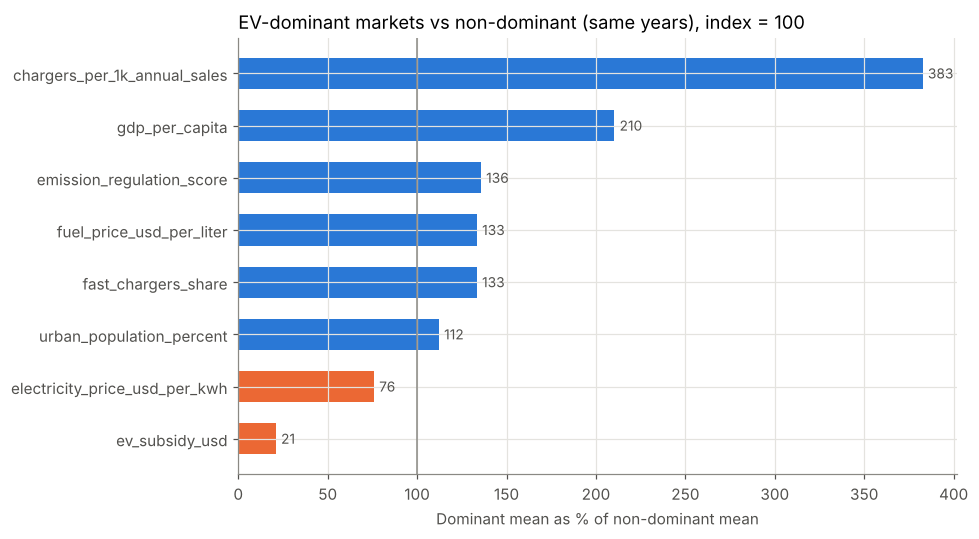

In [52]:
# Visual signature: dominant vs same-year non-dominant, indexed to non-dominant = 100
idx = (signature.dominant_mean / signature.non_dominant_mean_same_years * 100).drop("charging_stations").sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(idx.index, idx.values, color=[PALETTE[0] if v >= 100 else PALETTE[1] for v in idx.values], height=0.6)
ax.axvline(100, color="#8a8984", linewidth=1)
for i, v in enumerate(idx.values):
    ax.text(v + 3, i, f"{v:.0f}", va="center", fontsize=9, color="#52514e")
ax.set_title("EV-dominant markets vs non-dominant (same years), index = 100", loc="left")
ax.set_xlabel("Dominant mean as % of non-dominant mean")
plt.tight_layout()
plt.show()

In [53]:
# Country view: how the dominant countries score vs the rest in 2025 (percentile rank among 25 countries)
c25 = df[(df.year == LATEST) & (df.vehicle_segment == "mass_market")].set_index("country")
pct = c25[SIG[1:]].rank(pct=True) * 100
dom_countries = sorted(dom.country.unique())
pct.loc[dom_countries].round(0)

,chargers_per_1k_annual_sales,fast_chargers_share,ev_subsidy_usd,emission_regulation_score,fuel_price_usd_per_liter,electricity_price_usd_per_kwh,gdp_per_capita,urban_population_percent
country,,,,,,,,
China,84.000,100.000,20.000,64.000,28.000,8.000,28.000,24.000
Netherlands,100.000,4.000,52.000,92.000,100.000,84.000,88.000,96.000
Norway,96.000,80.000,20.000,98.000,96.000,44.000,96.000,72.000
Sweden,92.000,48.000,20.000,98.000,92.000,40.000,80.000,88.000


## Key findings: EV-dominant profile

**Who is dominant.** 22 segment-rows in **4 countries**: Norway (premium from 2019, mass market from 2020), Sweden (premium from 2021, mass market from 2024), China and the Netherlands (premium only, from 2025). No commercial segment is dominant. Closest to 50% in 2025: Germany premium (46.4%, 3.6 pp away), Belgium and Switzerland premium (41%), and China mass market (40.7%).

**Dominance signature** (dominant rows vs non-dominant rows in the same years, 2019 to 2025)

| Driver | Dominant mean | Non-dominant mean | Ratio |
|---|---|---|---|
| Emission regulation score | 93.3 | 68.8 | 1.36x |
| Charging stations (raw count) | 231,834 | 115,996 | 2.0x |
| Chargers per 1,000 annual sales (supplementary proxy) | 162 | 42 | 3.8x |
| Fast-charger share (%) | 29.0 | 21.7 | 1.33x |
| Fuel price (USD/l) | 1.99 | 1.49 | 1.33x |
| Electricity price (USD/kWh) | 0.147 | 0.193 | 0.76x |
| GDP per capita (USD) | 77,565 | 36,897 | 2.1x |
| EV subsidy (USD) | 721 | 3,445 | 0.21x |

**How dominant markets differ from non-dominant markets**
- **Top-tier emission regulation:** a median score of 93.8, higher than 98.6% of same-year non-dominant observations. This is the cleanest separation among the original drivers.
- **Higher charging availability:** the raw station count is about 2x higher on average, but the dominant median sits only at the 59th percentile of same-year non-dominant observations, because large markets have many stations regardless of adoption. Normalized by market size, the proxy is 3.8x higher (96th percentile of same-year non-dominant observations); given its shared denominator with EV share, this gap is read cautiously.
- **Higher fuel prices and lower electricity prices:** fuel is about a third more expensive and electricity about a quarter cheaper on average. This is consistent with more favorable relative operating-cost conditions for EVs; the dataset does not contain enough information (efficiency, mileage) to calculate actual running-cost differences.
- **Higher income, with one exception:** GDP per capita is about 2x higher. China is an exception to the high-income pattern: it reached premium-segment dominance despite below-median GDP, while also showing relatively strong regulation and charging availability.
- **Lower subsidies:** dominant observations have about one-fifth of the subsidy of same-year non-dominant observations (median 0). High subsidies are therefore not a necessary feature of already-dominant markets in this dataset; this does not show that subsidies are ineffective or that reducing them leads to dominance.

---
# 6. Key Adoption Patterns & Reasoning

**Method.** Work at country-year level (drivers are country-year values). Each driver is flagged **High** if it is above that year's cross-country median, so "high" always means high relative to peers in the same year, which removes the time trend. Outcomes:
- **EV share:** volume-weighted country share.
- **Fast growth:** next-year change in share (pp) and recomputed EV sales growth, used instead of `ev_growth_rate_yoy` because of the issues found in Section 1.
- **Early dominance:** any segment dominant, and the year each country first reached dominance.

**Interpretation limits.**
- These archetype comparisons are descriptive combinations, not controlled causal contrasts: several market characteristics differ at the same time between groups.
- "Charging" here uses the supplementary proxy from Section 4 (stations per 1,000 annual vehicle sales), because a raw station count mostly ranks market size. The proxy shares a denominator with EV share, so charging-based contrasts may overstate the charging relationship.

In [54]:
# Country-year panel with drivers and outcomes
ctx = df.groupby(["country", "year"])[["charging_stations", "chargers_per_1k_annual_sales", "fast_chargers_share", "fuel_price_usd_per_liter",
                                       "electricity_price_usd_per_kwh", "ev_subsidy_usd", "emission_regulation_score",
                                       "gdp_per_capita", "urban_population_percent"]].first()
panel = country_year.set_index(["country", "year"]).join(ctx).reset_index().sort_values(["country", "year"])
panel["any_dominant"] = df.groupby(["country", "year"]).is_ev_dominant.max().values
panel["premium_share"] = df[df.vehicle_segment == "premium"].set_index(["country", "year"]).ev_market_share.reindex(
    pd.MultiIndex.from_frame(panel[["country", "year"]])).values
panel["mass_share"] = df[df.vehicle_segment == "mass_market"].set_index(["country", "year"]).ev_market_share.reindex(
    pd.MultiIndex.from_frame(panel[["country", "year"]])).values

# Forward-looking growth outcomes (what happens next year)
panel["next_yr_share_change_pp"] = panel.groupby("country").ev_market_share.shift(-1) - panel.ev_market_share
panel["next_yr_ev_sales_growth_%"] = (panel.groupby("country").ev_sales.shift(-1) / panel.ev_sales - 1) * 100

# High / Low flags relative to the same-year median
for c in ["chargers_per_1k_annual_sales", "fuel_price_usd_per_liter", "emission_regulation_score", "ev_subsidy_usd", "gdp_per_capita"]:
    panel[f"hi_{c}"] = panel[c] > panel.groupby("year")[c].transform("median")

# Focus on the period when EV adoption is meaningful
P = panel[panel.year >= 2015].copy()
print(P.shape)

(275, 26)


In [55]:
def profile(mask, name):
    g = P[mask]
    return {
        "pattern": name,
        "n_country_years": len(g),
        "n_countries": g.country.nunique(),
        "mean_ev_share_%": g.ev_market_share.mean(),
        "median_ev_share_%": g.ev_market_share.median(),
        "mean_next_yr_share_change_pp": g.next_yr_share_change_pp.mean(),
        "median_next_yr_ev_sales_growth_%": g["next_yr_ev_sales_growth_%"].median(),
        "dominance_rate_%": g.any_dominant.mean() * 100,
    }

F, R, C, S, G = (P.hi_fuel_price_usd_per_liter, P.hi_emission_regulation_score, P.hi_chargers_per_1k_annual_sales,
                 P.hi_ev_subsidy_usd, P.hi_gdp_per_capita)

combos = pd.DataFrame([
    profile(P.year > 0, "All country-years (baseline)"),
    profile(F & R & C, "A: High fuel + High regulation + High charging"),
    profile(~F & ~R & ~C, "A-contrast: Low on all three"),
    profile(S & ~C, "B: High subsidy + Low charging"),
    profile(S & C, "B-contrast: High subsidy + High charging"),
    profile(~S & C, "B-contrast: Low subsidy + High charging"),
    profile(G & R & ~C, "C: High GDP + High regulation, Low charging"),
    profile(~G & R & C, "D: Below-median GDP + High regulation + High charging"),
    profile(G & ~R, "High GDP + Low regulation"),
]).set_index("pattern")
combos.round(2)

,n_country_years,n_countries,mean_ev_share_%,median_ev_share_%,mean_next_yr_share_change_pp,median_next_yr_ev_sales_growth_%,dominance_rate_%
pattern,,,,,,,
All country-years (baseline),275,25,9.880,3.090,2.040,38.900,5.090
A: High fuel + High regulation + High charging,98,11,19.840,18.220,3.540,25.900,13.270
A-contrast: Low on all three,116,11,2.840,0.950,0.890,47.590,0.000
B: High subsidy + Low charging,62,10,4.680,3.230,1.250,37.660,0.000
B-contrast: High subsidy + High charging,70,12,11.060,6.060,2.950,31.830,2.860
B-contrast: Low subsidy + High charging,62,11,23.580,21.910,3.620,29.180,19.350
"C: High GDP + High regulation, Low charging",6,2,12.040,11.450,1.070,33.590,0.000
D: Below-median GDP + High regulation + High charging,19,4,13.200,8.500,3.900,48.470,5.260
High GDP + Low regulation,34,4,4.800,2.310,1.280,33.340,0.000


In [56]:
# Which countries sit in each pattern most often (2021 to 2025)
recent = P[P.year >= 2021]
members = {
    "A: fuel+reg+charging": recent[F.loc[recent.index] & R.loc[recent.index] & C.loc[recent.index]].country.value_counts(),
    "B: subsidy, weak charging": recent[S.loc[recent.index] & ~C.loc[recent.index]].country.value_counts(),
    "D: mid-income, reg+charging": recent[~G.loc[recent.index] & R.loc[recent.index] & C.loc[recent.index]].country.value_counts(),
}
for k, v in members.items():
    print(f"{k}: {v.to_dict()}")

A: fuel+reg+charging: {'Austria': 5, 'Belgium': 5, 'France': 5, 'Germany': 5, 'Netherlands': 5, 'Norway': 5, 'Sweden': 5, 'Switzerland': 5, 'Portugal': 3, 'United Kingdom': 2, 'Spain': 1}
B: subsidy, weak charging: {'Canada': 5, 'Italy': 5, 'Japan': 5, 'Poland': 5, 'United States': 5, 'Turkey': 3, 'India': 2, 'Spain': 2}
D: mid-income, reg+charging: {'China': 5, 'Portugal': 3, 'Spain': 1}


In [57]:
# Premium early-adopter pathway: does high GDP mean a bigger premium lead and earlier premium take-off?
P["premium_minus_mass_pp"] = P.premium_share - P.mass_share
gdp_view = P.groupby("hi_gdp_per_capita").agg(
    mean_premium_share=("premium_share", "mean"),
    mean_mass_share=("mass_share", "mean"),
    mean_premium_minus_mass_pp=("premium_minus_mass_pp", "mean"),
    dominance_rate_pct=("any_dominant", lambda x: x.mean() * 100),
)
gdp_view.index = ["Below-median GDP", "Above-median GDP"]

# Year premium first crosses 10% by GDP group (GDP measured in 2015)
prem10 = timing[(timing.segment == "premium") & (timing.threshold == 10)].set_index("country").first_year
gdp15 = panel[panel.year == 2015].set_index("country").gdp_per_capita
hi_gdp = gdp15 > gdp15.median()
# Median crossing year among countries that crossed; counts show how many crossed by 2025
p10 = prem10.reindex(gdp15.index)
for lab, m in [("Above-median GDP", hi_gdp), ("Below-median GDP", ~hi_gdp)]:
    print(f"{lab}: {p10[m].notna().sum()}/{m.sum()} crossed 10% premium share, median first-crossing year = {p10[m].median()}")
gdp_view.round(2)

Above-median GDP: 12/12 crossed 10% premium share, median first-crossing year = 2020.0
Below-median GDP: 8/13 crossed 10% premium share, median first-crossing year = 2021.5


,mean_premium_share,mean_mass_share,mean_premium_minus_mass_pp,dominance_rate_pct
Below-median GDP,6.300,4.340,1.960,0.700
Above-median GDP,21.970,15.820,6.150,9.850


In [58]:
# Early dominance: driver profile in the year each country first became dominant
first_dom = P[P.any_dominant == 1].groupby("country").year.min()
early = []
for c, y in first_dom.items():
    row = P[(P.country == c) & (P.year == y)].iloc[0]
    early.append({"country": c, "first_dominant_year": y,
                  "high_fuel": row.hi_fuel_price_usd_per_liter, "high_regulation": row.hi_emission_regulation_score,
                  "high_charger_proxy": row.hi_chargers_per_1k_annual_sales, "high_subsidy": row.hi_ev_subsidy_usd,
                  "high_gdp": row.hi_gdp_per_capita})
pd.DataFrame(early).sort_values("first_dominant_year")

,country,first_dominant_year,high_fuel,high_regulation,high_charger_proxy,high_subsidy,high_gdp
2,Norway,2019,True,True,True,False,True
3,Sweden,2021,True,True,True,True,True
1,Netherlands,2025,True,True,True,False,True
0,China,2025,False,True,True,False,False


## Key findings: 3 adoption archetypes

Figures from the combination table (2015 to 2025, 275 country-years; baseline mean share 9.9%, next-year gain 2.0 pp, dominance rate 5.1%). All three are descriptive patterns; see the interpretation limits in the method note.

**1. "Full-Stack Push": high fuel price + strong regulation + high charging availability.**
Persistent members (meeting all three conditions in every year from 2021 to 2025): Norway, Sweden, Netherlands, Germany, France, Belgium, Austria and Switzerland. Portugal, the United Kingdom and Spain also enter this pattern in some years. Mean share 19.8% (2x baseline), next-year share gain 3.5 pp, dominance rate 13.3%. Country-years low on all three average only 2.8% share and none is dominant. Norway, Sweden and the Netherlands were all in this pattern in the year they first became dominant.
*Why it may be associated with higher adoption:* this combination captures markets where policy stringency, charging availability and ICE operating costs all point in an EV-supportive direction. The data show these conditions occurring together with higher EV share and faster share gains, but they cannot isolate the contribution of each component.

**2. "Subsidy Without Sockets" (lower-adoption pattern): high subsidy + low charging availability.**
Persistent members (2021 to 2025): United States, Canada, Japan, Italy and Poland. Turkey, India and Spain also appear in this pattern in some years. Mean share is 4.7%, well below the 9.9% baseline, with a next-year gain of 1.25 pp; the group records no dominant observations. Country-years with **low** subsidy and **high** charging availability average 23.6% share, 3.6 pp gains and a 19.4% dominance rate.
*What the pattern suggests:* strong subsidies alone are not sufficient to characterize high-adoption markets in this sample, while higher charging availability is consistently associated with higher EV share. The two groups differ on subsidy and charging at the same time (and on other drivers), so the gap is not a controlled estimate of either lever.

**3. "Premium Early-Adopter Pathway": high GDP, premium segment leads.**
Above-median GDP country-years average 22.0% premium share vs 6.3% for below-median. Among countries that reached 10% premium EV share by 2025, the median first-crossing year is 2020 for the above-median-GDP group (12/12 countries crossed) versus 2021.5 for the below-median-GDP group (8/13 crossed). Their premium-over-mass gap is about 3x larger (6.2 vs 2.0 pp), and the dominance rate is 9.9% vs 0.7%. High GDP combined with weak regulation averages only 4.8% share, so income alone does not describe the high-adoption group.
*Interpretation:* one possible reading is that higher-income markets may support earlier premium-segment adoption. The data directly show earlier premium uptake in higher-GDP markets, but they contain no buyer-level affordability or model-launch information, so that mechanism is not tested here. China illustrates the counter-example: it has below-median GDP while also showing strong regulation, high charging availability and premium dominance in 2025. More broadly, the below-median-GDP + high-regulation + high-charging group (19 country-years, mostly China and Portugal, plus two Spain years and one France year) has the largest average next-year share gain among the displayed combinations (3.9 pp).

*Growth note:* median percentage growth in EV sales is higher in low-adoption groups because they start from a tiny base; percentage-point share gains are the more meaningful growth measure here.

---
# 7. Operational & Business Implications

In [59]:
# Supporting numbers for the recommendations
imp = {}
imp["region_share_2025"] = region_share.loc[LATEST].round(1).to_dict()
imp["commercial_share_2025_weighted"] = round(seg_profile.loc["commercial", f"weighted_ev_share_{LATEST}"], 1)
imp["premium_share_2025_weighted"] = round(seg_profile.loc["premium", f"weighted_ev_share_{LATEST}"], 1)
imp["chargers_per_1k_2025_bottom5"] = c25.chargers_per_1k_annual_sales.nsmallest(5).round(1).to_dict()
imp["large_markets_low_share"] = country_latest[(country_latest.total_vehicle_sales > 1.5e6) & (country_latest.ev_market_share < 15)] \
    .set_index("country")[["total_vehicle_sales", "ev_market_share"]].round(1).to_dict("index")
for k, v in imp.items():
    print(f"{k}: {v}")

region_share_2025: {'APAC': 30.5, 'Europe': 24.4, 'North America': 12.2, 'Oceania': 12.3, 'South America': 4.1}
commercial_share_2025_weighted: 8.3
premium_share_2025_weighted: 34.3
chargers_per_1k_2025_bottom5: {'Mexico': 5.6, 'India': 6.2, 'Brazil': 6.5, 'United States': 8.0, 'Indonesia': 9.4}
large_markets_low_share: {'Brazil': {'total_vehicle_sales': 2538623, 'ev_market_share': 4.1}, 'India': {'total_vehicle_sales': 5581196, 'ev_market_share': 3.2}, 'Italy': {'total_vehicle_sales': 1609382, 'ev_market_share': 12.3}, 'Japan': {'total_vehicle_sales': 4711120, 'ev_market_share': 5.9}, 'United States': {'total_vehicle_sales': 16484616, 'ev_market_share': 12.6}}


## Recommendations

These recommendations build on observed associations. They indicate where to focus and what to evaluate further; they do not estimate the return from any specific intervention.

**Government / regulators**
- **Consider emission regulation as part of a broader adoption package.** Regulation has the strongest within-year association with EV share (rho = 0.87). Dominant observations also have substantially higher regulation scores on average (93.3 vs 68.8 for same-year non-dominant observations), although the dominant countries are not uniformly at the very top of the distribution (China is at the 64th percentile in 2025). In the joint model (4.5 to 4.9) it is the most robust association in the analysis, holding across countries, within countries over time and under the small-cluster bootstrap, although it overlaps substantially with charging infrastructure.
- **Prioritize charging availability alongside purchase incentives.** Charging stations are the second-strongest original driver (within-year rho 0.72), remain positive and significant when modeled jointly with regulation, and "high subsidy + low charging" country-years average 4.7% share. The analysis does not establish the causal return from additional chargers.
- **Do not rely on subsidies alone.** High-subsidy, low-charging observations have low EV shares, while already-dominant observations have lower subsidies than their peers. Within countries, years with higher-than-usual subsidies do show higher EV share (4.7), so subsidies are not irrelevant; the cross-country pattern shows that subsidy levels do not distinguish high-adoption markets. This suggests evaluating incentives together with infrastructure rather than assuming larger subsidies alone will raise adoption.
- **Commercial vehicles are the least-electrified segment in the dataset.** Weighted EV share is 8.3% in 2025, no country is above 50%, and only 5 countries have passed 10%. The segment may warrant targeted investigation or pilot policies; interventions such as depot charging or fleet-focused policies could be evaluated there.

**Charging network operators**
- **Potential expansion candidates:** the United States (8.0 stations per 1,000 annual sales, 12.6% share), India (6.2, 3.2%), Brazil (6.5, 4.1%) and Mexico (5.6, 3.4%) combine relatively low charging availability with low EV share; the US, India and Brazil are also among the larger vehicle markets in the sample.
- **Use market size alongside raw station counts when planning capacity.** Raw counts are dominated by market size (China holds 73% of stations in 2025), while ratios to annual sales share a denominator with EV share, so neither should be used alone.
- **Near-dominant markets are useful candidates for further analysis of fast-charging needs.** Germany premium (3.6 pp from 50%), Belgium and Switzerland premium and China mass market (about 9 pp away) are closest to the threshold; this dataset does not establish that more fast chargers would move them across it.

**Automakers**
- **Europe: room for mass-market EV penetration to catch up.** Premium EV share is already 36 to 95% in the ten leading European share markets, and mass-market EV share generally remains below premium share across them.
- **APAC: China combines very large EV volume with a premium to mass-market gap.** It accounts for about 66% of EV sales in the 25-country sample in 2025 and has the steepest 2020 to 2025 share slope (7.1 pp/yr), with premium share at 59% vs 40.7% for mass market, making the mass-market segment an important area for further strategy analysis.
- **North America, Oceania, South America: premium-led entry could be considered.** These regions sit at 4 to 12% share. The observed premium-first diffusion pattern suggests a premium-led entry strategy there, with mass-market expansion evaluated as infrastructure and adoption mature. For Oceania and South America this should be treated cautiously, because each region is represented by only one country in the dataset (Australia and Brazil).